
> A Note on the Code
> 
> This project incorporates concepts from some of my previous, unpublished coding projects. To avoid any potential for self-plagiarism, I have made my best effort to rewrite, repurpose, and refine any adapted code. The final submission is therefore original work developed specifically for this project. I've done my best to ensure that this project is not a replication of my previous work, and none of which has been submitted to any institution for a certificate, degree, or diploma.


## Project Overview

> An introduction


I've developed a comprehensive Python framework to help us build, back-test, and simulate live trading for our algorithmic strategies. It brings together all the essential components we'll need, including data processing, strategy definition, risk management, performance analysis, and even direct connectivity to brokerage APIs like Alpaca.

The primary objective of this study is to implement and evaluate three distinct strategies, covering two fundamental approaches: trend-following and mean-reversion. Specifically, we will develop:

1.  A Mean-Reversion Strategy: This model uses a Z-Score to identify statistically significant deviations from a rolling mean. To enhance signal quality, this strategy optionally employs a Kalman Filter to estimate the 'true' underlying price, thereby reducing the impact of market noise.

2.  A classic Trend-Following Strategy: This implementation uses an Exponential Moving Average (EMA) Crossover for primary signal generation, which is then filtered by the Average Directional Index (ADX) to ensure trades are only initiated during periods of high-conviction trend strength.

3.  A Momentum/Ratio-Based Strategy: As a second, distinct trend-following approach, this strategy calculates the ratio of the current price to its long-term moving average to generate momentum-based trading signals.

Also, in this Jupyter Notebook, I'll walk you through the framework's key features. We will cover:

* An End-to-End Trading Ecosystem: The framework integrates every stage of the trading process, from persistent data collection (TimescaleDB), to strategy development (strategies.py), rigorous backtesting and optimization (backtest_utils.py), and finally to live paper trading with a resilient, asynchronous engine (run_live_trading.py).

* A Production-Grade Architecture: The entire application is containerized using a multi-stage Dockerfile and orchestrated with Docker Compose, ensuring a reproducible and isolated environment. Furthermore, cron-style scheduling with GitHub Actions automates critical operational tasks such as daily data updates and weekly back-tests, showcasing a design built for autonomous operation.

* A Robust Data-Centric Design: At its core lies a high-performance TimescaleDB database, which acts as the "single source of truth" for both historical market data and live trading logs. This, combined with a two-level caching strategy, minimizes API dependency, accelerates performance, and guarantees data integrity across all modules.

* Advanced Risk and Performance Analytics: The PerformanceAnalyzer provides deep insights into trading costs, turnover, and risk-adjusted returns (e.g., Sharpe, Sortino, Calmar ratios), while the RiskManager actively calculates Value-at-Risk (VaR) and validates data quality in real-time.

* Resilience and Rigorous Validation: Acknowledging the fragility of live operations, the system features a centralized ExceptionHandler with automated retries, a resilient WebSocket reconnection mechanism, and a state verification loop to guard against inconsistent broker data. Crucially, the ConsistencyValidator module directly addresses the "test thrice" principle by providing a quantitative tool to measure and minimize the backtest-to-live reality gap.


### How to Run (Command-Line Tools)

The framework provides the ease of use and automation, offering simple command-line entry points for its core functions. After installation, we can execute the following scripts directly from our terminal:

#### Run Backtests & Optimizations

```bash
run-backtest
```

* Purpose: Executes the complete back-testing and strategy optimization process.

* Function: It tests strategies against historical data, leveraging the backtrader engine. The script intelligently loads data from the local TimescaleDB database first, and only fetches from the Alpaca API if the required data is missing, saving any new data back to the database.

#### Live Trader

```bash
run-live
```

* Purpose: Deploys the trading bot for live or paper trading.

* Function: This command starts the asynchronous trading application, connects to the Alpaca API via WebSockets for real-time data, and executes trades based on the live strategy logic. By default, it runs in paper trading mode.

#### Downloads the Latest Market Data

```bash
run-update-data
```

* Purpose: Downloads the latest market data to keep our local database current.

* Function: This script launches a job to fetch recent historical bar data from the Alpaca API and persists it in your TimescaleDB database, ensuring our back-tests are always run on up-to-date information.

#### Creates a Daily Performance and Risk Report

```bash
run-generate-report
```

* Purpose: Creates a daily performance and risk report.

* Function: It queries the database to gather trade fills and performance snapshots, then generates a comprehensive report in JSON format, summarizing metrics like P&L, Sharpe Ratio, and drawdown.

#### Performance Dashboard

```bash
run-dashboard
```

* Purpose: Launches an interactive web-based performance dashboard.

* Function: This command starts a Streamlit application that connects to the TimescaleDB database and provides a rich, visual interface for analyzing live trading performance, account metrics, and risk exposure.


### Run with Docker (Containerization)

Docker container is a containerized way to run the live trader, and it can manage both the trading bot and the database.

```bash
docker-compose up --build
```

This single command will:

* Pull the timescale/timescaledb-ha image for the database.

* Build the patf-trading-framework:latest image for our trading bot.

* Start both containers in the correct order (depends_on).

* Pass the POSTGRES_PASSWORD from our .env file securely to both containers.

* Mount the output/ and database data directories to persist logs and data on our host machine.

* Start the run-live command inside the trading bot container.



### Run Integration Tests

To verify that our Alpaca API keys and database connection are working, run the integration tests using pytest.

```bash
pytest tests/integration/test_broker_integration.py

pytest tests/integration/test_db_integration.py
```


## Functionality Checklist

> A breakdown of each requirement, its status, and the evidence from our codebase


### Functionality Checklist

This checklist details how the project's features and implementation map directly to the requirements outlined in the `project_requirements.md` brief.

**Status Legend**

| Status | Description |
| :--- | :--- |
| **Met** | The requirement is fully implemented and functional. |
| **Partially Met** | The requirement is addressed, but could be expanded. |
| **Not Met** | The requirement is not implemented. |

<br>

### Part I: Generic Strategies Made Proprietary

| Requirement | Status | Evidence / Justification |
| :--- | :--- | :--- |
| Implement at least two trend-following strategies. | **Met** | The project implements two distinct trend-following strategies in `src/patf_trading_framework/strategies.py`: <br> 1. **`EMACrossoverStrategy`**: A classic strategy using Exponential Moving Averages (EMA) and the Average Directional Index (ADX). <br> 2. **`CustomRatioStrategy`**: A momentum strategy based on the ratio of the current price to its long-term moving average, directly fulfilling requirement I.2. |
| Implement at least one mean-reversion strategy. | **Met** | The **`MeanReversionZScoreStrategy`** in `src/patf_trading_framework/strategies.py` is a complete implementation of a mean-reversion strategy using Z-Score for signal generation. |
| Experiment with different timeframes and parameters. | **Met** | The backtesting framework is designed for experimentation. <br> - **`config.yml`** allows easy changes to the resampling timeframe (`timeframe_value`, `timeframe_unit`). <br> - The `opt_ranges` section for each strategy in `config.yml` enables parameter optimization, executed by the `run-backtest` script. |
| (Optional) Apply price filtering for the mean-reversion strategy. | **Met** | This optional requirement was fully implemented. <br> - The **Kalman Filter** is implemented in `src/patf_trading_framework/data_utils.py` (`apply_kalman_filter`). <br> - The `MeanReversionZScoreStrategy` explicitly checks for the `use_filtered_price` parameter in `config.yml` to use the smoothed price data. |

<br>

### Part II: Broker API and Input Data

| Requirement | Status | Evidence / Justification |
| :--- | :--- | :--- |
| Fetch data from a professional brokerage source. | **Met** | The project exclusively uses the **Alpaca API** for both historical data fetching (`get_bars`) and live streaming, as seen in `src/patf_trading_framework/broker_handler.py` and `data_utils.py`. |
| Write routines to check data quality. | **Met** | The `RiskManager` class in `src/patf_trading_framework/risk_manager.py` contains a `validate_market_data` method. It checks for invalid data (price <= 0), unusual price jumps, and volume spikes. |
| Use a REST API for non-time-critical operations. | **Met** | The `BrokerAPIHandler` in `src/patf_trading_framework/broker_handler.py` is built entirely around Alpaca's **v2 REST API**. It handles fetching account info, placing/canceling orders, and listing positions. |
| Use asynchronous events (WebSockets) for real-time data. | **Met** | The live trading system (`run_live_trading.py`) is built on `asyncio`. The `BrokerAPIHandler` manages the **WebSocket data stream** (`setup_stream`, `start_streaming`) to receive real-time updates asynchronously. |
| Handle exceptions and inconsistent broker data. | **Met** | The framework addresses this robustly: <br> 1. **`ExceptionHandler`**: Catches, classifies, and logs errors from the API, network, and order execution. Includes a `CircuitBreaker` pattern. <br> 2. **Verification Loop**: `run_live_trading.py` includes a periodic loop (`_verify_state_once`) that polls the REST API to synchronize the bot's state with the broker, detecting discrepancies. <br> 3. **Retry Logic**: `BrokerAPIHandler` implements an automated retry mechanism with exponential backoff for REST API calls. |
| Consider liquidity, market impact, and market events. | **Met** | **`risk_manager.py`** contains the `check_liquidity_and_impact` and `check_leverage_and_exposure` methods, which act as pre-trade checks. <br> - These are configured in `config.yml` with parameters like `max_order_participation_ratio` and `market_impact_coefficient`. <br> - Sudden events are monitored via `validate_market_data` which checks for price/volume spikes. |

<br>

### Part III: Evaluate Risk and Test Thrice

| Requirement | Status | Evidence / Justification |
| :--- | :--- | :--- |
| Containerize the application (Docker). | **Met** | The project is fully containerized. <br> - A multi-stage **`Dockerfile`** builds an optimized image. <br> - **`docker-compose.yml`** orchestrates the trading bot and the TimescaleDB database, enabling a one-command deployment (`docker-compose up`). |
| Use cron-style scheduling. | **Met** | This is implemented using **GitHub Actions**. The `.github/workflows/schedule.yml` file uses cron syntax to trigger workflows for daily data updates and weekly backtests. |
| Implement a secondary confirmation layer for positions. | **Met** | This is a core feature of the live trading system. <br> - `TradingState` in `src/patf_trading_framework/live_components.py` tracks the bot's internal position. <br> - `run_live_trading.py` receives order updates via WebSocket and also periodically polls the REST API (`get_position`) to verify and synchronize the state. |
| Catch and handle stale WebSockets and connection issues. | **Met** | The live trading loop in `run_live_trading.py` (`_run_stream_with_reconnect`) is a resilient reconnection mechanism for the WebSocket. It catches connection errors (`websockets.exceptions.ConnectionClosedError`) and attempts to reconnect with an exponential backoff delay. The `ExceptionHandler` provides centralized logging for these events. |
| Report on P&L, turnover, trading costs, and drawdown. | **Met** | The `PerformanceAnalyzer` in `src/patf_trading_framework/performance_analyzer.py` is a comprehensive module that calculates and reports on all of these metrics and more, including risk-adjusted returns (Sharpe, Sortino, Calmar). |
| Implement a risk dashboard (TimescaleDB + Streamlit). | **Met** | This optional recipe was fully implemented. <br> - **`db_handler.py`** provides the interface to a persistent **TimescaleDB** database. <br> - `scripts/run_dashboard.py` launches a **Streamlit** application that connects to this database and displays KPIs and charts. <br> - The `docker-compose.yml` file manages the `timescale/timescaledb-ha` service. |
| Calculate Value-at-Risk (VaR). | **Met** | The `RiskManager` class in `src/patf_trading_framework/risk_manager.py` contains the `calculate_var` method, which can compute VaR using both historical and parametric methods. |
| Adhere to the "Test Thrice" Principle. | **Met** | The **`ConsistencyValidator`** module (`src/patf_trading_framework/consistency_validator.py`) directly addresses this core principle. It provides a quantitative framework to measure and report on the "reality gap" by comparing backtest results against live/paper trading results, validating execution fidelity. |

## Environment Setup and Configuration

> Ensure reproducibility of the project.


To get started, we'll need to set up the project environment. We have two main options: a local Python environment, which is great for direct development and testing, or a Docker environment, which is preferable for ensuring reproducibility and preparing for deployment.

### Option 1: Local Python Environment (Recommended: uv)
This option lets us develop and test the framework directly on our machine. We recommend using `uv` for the fastest setup.

```bash
# Create and activate the virtual environment
uv venv
source .venv/bin/activate

# Install in editable mode with development dependencies
uv pip install -e .[dev]
```

What this command does:

* `uv venv`: Creates a fast, standard virtual environment.

* `-e`: Installs the project in editable mode, so our code changes are reflected instantly.

* `[dev]`: Installs extra development tools such as `ruff`.

### Option 2: Docker Setup (Recommended for Reproducibility)

Using Docker is our recommended approach because it creates a consistent and isolated environment. This is perfect for ensuring everything works the same way across different machines, in CI/CD pipelines, and in production.

The whole process is handled by Docker Compose. Here’s what happens when we run it:

1. First, make sure we've set the required environment variables on our host machine (we'll cover that in the section below).

2. Then, run the following command in our terminal: docker compose up --build

When we run this, Docker Compose springs into action:

* It reads the docker-compose.yml file to understand how to build and run the services.

* It first checks the .dockerignore file to exclude things like venv/, .git/, or .env. This keeps the build context small, which makes the process faster and more secure.

* It then follows the steps in the Dockerfile to build a clean and optimized image named patf-trading-framework:latest.

* Once the image is ready, Docker Compose starts a container from it.

* During startup, it cleverly mounts our local output folder to /app/output inside the container. This ensures that any logs or charts the bot generates are saved directly to our machine.

* Finally, it executes the CMD instruction from the Dockerfile (which is run-live), officially starting the trading bot inside its own isolated environment.

### Handling API Keys with Docker

For security reasons, we should never hardcode API keys or other secrets directly into a Docker image. Instead, our docker-compose.yml file is set up to securely read these values from our host machine's environment variables.

Before we run docker-compose up, we'll need to export the following environment variables on our system:

```bash
export APCA_API_KEY_ID="our_paper_api_key_id"
export APCA_API_SECRET_KEY="our_paper_api_secret_key"
```

This approach keeps our sensitive keys safely separated from the application code and the Docker image, which is a standard security best practice.

### Loading configuration and API keys

For this notebook, we'll be using a local development setup, since running the Docker version directly within a Jupyter environment isn't practical. To keep things simple, we'll load our framework configuration from config.yml and the Alpaca API key from the .env file.

In [1]:
# Import standard libraries
import logging
import os
import re
import sys

import matplotlib.pyplot as plt
import yaml
from alpaca_trade_api.rest import REST  # <-- Import REST here
from dotenv import load_dotenv

# --- Configure Matplotlib for inline display in Jupyter ---
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
print("Standard libraries imported successfully.")

# --- Add project source directory to Python's path ---
try:
    project_dir = os.path.abspath('..')
    src_path = os.path.join(project_dir, 'src')
    if src_path not in sys.path:
        sys.path.insert(0, src_path)
    print(f"Project 'src' directory added to system path: {src_path}")
except Exception as e:
    print(f"Error adding path: {e}")

# --- Load environment variables from .env file ---
if load_dotenv(dotenv_path=os.path.join(project_dir, '.env')):
    print(".env file loaded successfully.")
else:
    print(".env file not found. Please ensure it is in the project root directory.")

# --- Helper function to substitute environment variables ---
def _sub_env_in_notebook(s: str) -> str:
    def repl(m):
        expr = m.group(1)
        if ":-" in expr:
            var, default = expr.split(":-", 1)
            return os.getenv(var, default)
        return os.getenv(expr, m.group(0))
    return re.sub(r'\$\{([^}]+)\}', repl, s)

# --- Load config.yml WITH environment substitution ---
config_path = os.path.join(project_dir, 'config.yml')
config = {}
try:
    with open(config_path, encoding='utf-8') as f:
        raw_content = f.read()
    substituted_content = _sub_env_in_notebook(raw_content)
    config = yaml.safe_load(substituted_content)
    print(f"{config_path} file loaded and variables substituted successfully.")
    print(f"Database port: {config['database']['port']} (Type: {type(config['database']['port'])})")
except Exception as e:
    print(f"Error loading configuration file: {e}")

# --- Configure logging ---
log_config = config.get('logging', {})
logging.basicConfig(
    level=getattr(logging, log_config.get('level', 'INFO').upper()),
    format=log_config.get('format', '%(asctime)s - %(name)s - %(levelname)s - %(message)s'),
    datefmt=log_config.get('datefmt', '%Y-%m-%d %H:%M:%S'),
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)
logger.info("Logging system configuration complete.")

# --- Initialize Alpaca API Globally ---
api = None  # Initialize to None in case of failure
try:
    API_KEY = os.getenv("APCA_API_KEY_ID")
    SECRET_KEY = os.getenv("APCA_API_SECRET_KEY")
    BASE_URL = os.getenv("ALPACA_BASE_URL", "https://paper-api.alpaca.markets")

    if not API_KEY or not SECRET_KEY:
        raise ValueError("Alpaca API Key/Secret not found in environment variables.")

    api = REST(API_KEY, SECRET_KEY, base_url=BASE_URL)
    account_info = api.get_account()
    print(f"Alpaca API initialized successfully. Account Status: {account_info.status}")
except Exception as e:
    print(f"ERROR: Failed to initialize Alpaca API: {e}")

2025-08-19 17:49:36 - __main__ - INFO - Logging system configuration complete.
2025-08-19 17:49:36 - urllib3.connectionpool - DEBUG - Starting new HTTPS connection (1): paper-api.alpaca.markets:443


Standard libraries imported successfully.
Project 'src' directory added to system path: C:\Users\gbyha\Documents\GitHub\algorithmic-trading-framework\src
.env file loaded successfully.
C:\Users\gbyha\Documents\GitHub\algorithmic-trading-framework\config.yml file loaded and variables substituted successfully.
Database port: 5432 (Type: <class 'int'>)


2025-08-19 17:49:37 - urllib3.connectionpool - DEBUG - https://paper-api.alpaca.markets:443 "GET /v2/account HTTP/1.1" 200 None


Alpaca API initialized successfully. Account Status: ACTIVE


## Models and Methodology

> The mathematical and numerical frameworks


In this chapter, we detail the mathematical and numerical frameworks underpinning the three distinct trading strategies we evaluate in this project. We designed the framework to be modular, consisting of a common data and execution layer that we apply to two classes of signal generation: mean-reversion and trend-following. We use a consistent notation throughout to ensure clarity.

### Common Framework: Data, Notation, and Resampling

All our strategies operate on a unified data structure. First, we resample raw, high-frequency price data to a standardized interval (bar), which we define by a frequency parameter, $f$. We outline the common notation we use for all subsequent model descriptions below.

| Symbol | Description |
| :--- | :--- |
| $f$ | The resampling frequency for price bars, where $f \in \{5\text{m}, 15\text{m}, 60\text{m}, 1\text{D}\}$. |
| $P_t^{(f)}$ | The observed closing price of the asset at time $t$ for the given frequency $f$. |
| $\hat{x}_t$ | The estimated (Kalman-filtered) "true" price of the asset at time $t$. |
| $k$ | A generic lookback period (window size) for a given indicator. |
| $S_t$ | A generic target position state (+1 for long, -1 for short, 0 for flat). |
| $w_t$ | The target position size (weight) for a trade at time $t$. |

### Mean-Reversion Strategy: Kalman-Filtered Z-Score

We designed this strategy to capitalize on statistically significant, short-term deviations from a rolling mean, with the expectation that the price will revert. To enhance signal quality, we first apply a state-space model to filter market noise.

#### State Estimation with the Kalman Filter

To improve the signal-to-noise ratio, we apply a Kalman Filter to the raw price series $P_t^{(f)}$. We model the asset's "true" unobserved price, $\hat{x}_t$, as a simple random walk, and the observed price $P_t^{(f)}$ as a noisy measurement of this true price. This defines a one-dimensional state-space model:

$$
\begin{aligned}
\text{State Equation:} \quad x_{t} &= x_{t-1} + w_{t}, \quad w_t \sim \mathcal{N}(0, \sigma_w^2) \\
\text{Observation Equation:} \quad P_{t}^{(f)} &= x_{t} + v_{t}, \quad v_t \sim \mathcal{N}(0, \sigma_v^2)
\end{aligned}
$$

The filter iteratively performs a predict-update cycle to estimate $\hat{x}_t$. The key update equation is:

$$ \hat{x}_{t|t} = \hat{x}_{t|t-1} + K_t (P_t^{(f)} - \hat{x}_{t|t-1}) $$

where $K_t$ is the Kalman Gain, which dynamically balances the confidence between the model's prediction ($\hat{x}_{t|t-1}$) and the new observation ($P_t^{(f)}$). We then use the filtered series $\hat{x}_t$ as the input for signal generation.

#### Z-Score Signal Generation

We base the trading signal on the Z-Score, which measures how many standard deviations the current filtered price is from its rolling mean.

$$ Z_t = \frac{\hat{x}_t - \mu_t^{(k_z)}}{\sigma_t^{(k_z)}} $$

Where:

* $\mu_t^{(k_z)}$ is the Simple Moving Average (SMA) of $\hat{x}_t$ over the lookback period $k_z$.

* $\sigma_t^{(k_z)}$ is the rolling standard deviation of $\hat{x}_t$ over the same period.

We define the trading logic with three thresholds: an upper entry limit ($\theta_{\text{upper}}$), a lower entry limit ($\theta_{\text{lower}}$), and a neutral exit threshold ($\theta_{\text{exit}}$).

* Long Entry Signal: We enter a long position ($S_t = +1$) when the price is statistically oversold:
    $$ Z_t < \theta_{\text{lower}} \quad (\text{e.g., } -2.0) $$

* Short Entry Signal: We enter a short position ($S_t = -1$) when the price is statistically overbought:
    $$ Z_t > \theta_{\text{upper}} \quad (\text{e.g., } +2.0) $$

* Exit Condition: We close any open position when the Z-Score reverts towards the mean:
    $$ (\text{if long: } Z_t \ge \theta_{\text{exit}}) \lor (\text{if short: } Z_t \le \theta_{\text{exit}}) \quad (\text{e.g., } \theta_{\text{exit}} = 0.0) $$

### Trend-Following Strategies

We implement two distinct trend-following models. Both aim to profit from sustained directional market movements but use different indicators to identify trends.

#### EMA Crossover with ADX Filter

The Average Directional Index (ADX) is more complex than a simple moving average because it's derived from several intermediate components. It was developed by J. Welles Wilder to measure the strength of a trend, regardless of its direction. The calculation, typically over a 14-period window, involves the following steps.

##### Step 1: Calculate the True Range (TR)

The True Range is the greatest of the following three values for a given period:

* Current High minus Current Low

* Absolute value of (Current High minus Previous Close)

* Absolute value of (Current Low minus Previous Close)

$$TR_t = \max[(H_t - L_t), \text{abs}(H_t - C_{t-1}), \text{abs}(L_t - C_{t-1})]$$

Where $H_t$, $L_t$, and $C_{t-1}$ are the current high, current low, and previous close, respectively.

##### Step 2: Calculate Directional Movement (+DM and -DM)

Directional Movement indicates whether the trend is upward or downward.

* UpMove = Current High - Previous High

* DownMove = Previous Low - Current Low

The Positive (+DM) and Negative (-DM) Directional Movements are then determined:

* If UpMove > DownMove and UpMove > 0, then $+DM_t = \text{UpMove}$. Otherwise, $+DM_t = 0$.

* If DownMove > UpMove and DownMove > 0, then $-DM_t = \text{DownMove}$. Otherwise, $-DM_t = 0$.

##### Step 3: Smooth the TR, +DM, and -DM

These values are smoothed over the indicator's period (N), which is typically 14. Wilder used a specific smoothing technique, which is similar to an Exponential Moving Average.

The first smoothed value is a simple sum over the first N periods:

* First $TR_{14} = \sum_{t=1}^{14} TR_t$

Subsequent values are smoothed as follows:

* $SmoothedTR_t = SmoothedTR_{t-1} - \frac{SmoothedTR_{t-1}}{N} + TR_t$ The same smoothing formula is applied to +DM and -DM.

##### Step 4: Calculate the Directional Indicators (+DI and -DI)

The Directional Indicators normalize the smoothed directional movements as a percentage of the smoothed True Range.

* $+DI_t = 100 \times \frac{Smoothed(+DM_t)}{SmoothedTR_t}$

* $-DI_t = 100 \times \frac{Smoothed(-DM_t)}{SmoothedTR_t}$

##### Step 5: Calculate the Directional Movement Index (DX)

The DX measures the absolute difference between +DI and -DI as a percentage of their sum. This value quantifies the momentum of the trend.

$$DX_t = 100 \times \frac{\text{abs}(+DI_t - (-DI_t))}{(+DI_t + (-DI_t))}$$

##### Step 6: Calculate the Average Directional Index (ADX)

The final ADX is a smoothed average of the DX values, which makes the indicator less volatile and more reliable for gauging trend strength.

* The first ADX value is a simple N-period average of DX: $ADX_{initial} = \frac{1}{N} \sum_{t=1}^{N} DX_t$

* Subsequent ADX values are smoothed: $ADX_t = \frac{(ADX_{t-1} \times (N-1)) + DX_t}{N}$

##### The Warm-Up Period Explained

Because the ADX calculation involves multiple layers of smoothing (for TR, DM, and DX), it requires a significant amount of historical data to produce a stable and accurate value.

For a 14-period ADX:

1. The first smoothed TR and DM values are only available after the 14th bar.

2. The first DX value requires the smoothed DI values.

3. The first ADX value is an average of the first 14 DX values, meaning you need at least 28 periods (14 for the initial smoothing + 14 for the first DX average) to get the very first ADX reading.

Due to this multi-stage smoothing, many technical analysts suggest that the ADX may need up to 150 periods of data for its value to fully converge and stabilize. This is important for backtesting, as it means the strategy will not generate signals in the initial portion of the dataset.

##### Application to our project

This classic trend-following model uses the crossover of two Exponential Moving Averages (EMAs) to determine trend direction, which we filter with the Average Directional Index (ADX) to gauge trend strength.

We calculate the EMA at time $t$ for a period $k$ recursively:

$$ \text{EMA}_t^{(k)} = \alpha_k P_t^{(f)} + (1-\alpha_k)\text{EMA}_{t-1}^{(k)}, \quad \text{where} \quad \alpha_k = \frac{2}{k+1} $$

##### Average Directional Index (ADX) Formulation

To ensure trades are only initiated during periods of high-conviction trends, we use the ADX as a filter. The ADX is a non-directional indicator that quantifies the strength of a trend. Its calculation for a period $N$ (typically 14) is a multi-step process:

1. True Range (TR): First, we determine the True Range, which is the greatest of the current period's high-low range or the absolute difference between the current high/low and the previous close.

  $$ TR_t = \max[(H_t - L_t), \text{abs}(H_t - C_{t-1}), \text{abs}(L_t - C_{t-1})] $$

2. Directional Movement (+DM, -DM): We then calculate the positive and negative directional movements.

  $$ \text{UpMove} = H_t - H_{t-1} $$

  $$ \text{DownMove} = L_{t-1} - L_t $$

  $$ +DM_t = \begin{cases} \text{UpMove} & \text{if UpMove > DownMove and UpMove > 0} \\ 0 & \text{otherwise} \end{cases} $$

  $$ -DM_t = \begin{cases} \text{DownMove} & \text{if DownMove > UpMove and DownMove > 0} \\ 0 & \text{otherwise} \end{cases} $$

3. Smoothed Indicators: The TR, +DM, and -DM values are smoothed over the period $N$ using Wilder's smoothing method. For any series $X$:

  $$ SmoothedX_t = SmoothedX_{t-1} - \frac{SmoothedX_{t-1}}{N} + X_t $$

4. Directional Indicators (+DI, -DI): The smoothed movements are normalized by the smoothed True Range.

  $$ +DI_t = 100 \times \frac{Smoothed(+DM_t)}{SmoothedTR_t} $$

  $$ -DI_t = 100 \times \frac{Smoothed(-DM_t)}{SmoothedTR_t} $$

5. Directional Index (DX) and ADX: Finally, the Directional Index (DX) is calculated, and its smoothed value gives the ADX.

  $$ DX_t = 100 \times \frac{\text{abs}(+DI_t - (-DI_t))}{(+DI_t + (-DI_t))} $$

  $$ ADX_t = \frac{(ADX_{t-1} \times (N-1)) + DX_t}{N} $$

A warm-up period is necessary for the ADX to generate stable values due to the multiple layers of smoothing. For a 14-period ADX, at least 28 data points are required for the first calculation, with the indicator becoming more reliable as more data is processed. Our backtesting framework correctly handles this by waiting for the indicator to yield valid numbers before evaluating signals.

* Long Entry Signal (Golden Cross): We initiate a long position ($S_t = +1$) when the fast EMA (period $k_s$) crosses above the slow EMA (period $k_l$), and the ADX confirms a strong trend:

  $$ (\text{EMA}_t^{(k_s)} > \text{EMA}_t^{(k_l)} \quad \text{and} \quad \text{EMA}_{t-1}^{(k_s)} \le \text{EMA}_{t-1}^{(k_l)}) \quad \text{AND} \quad \text{ADX}_t^{(k_{adx})} \ge \theta_{adx} $$

* Exit Signal (Death Cross): We close the long position when the fast EMA crosses below the slow EMA.

#### Custom Strategy: Price-to-MA Ratio

This model quantifies trend strength by measuring the ratio of the current price to a single long-term moving average.

1. Moving Averages: We compute a short-term SMA, $S_t = \text{SMA}(P_t^{(f)}, n_s)$, and a long-term SMA, $L_t = \text{SMA}(P_t^{(f)}, n_l)$.

2. Primary Signal Ratio ($R_t$): The central signal is the ratio $R_t = S_t / L_t$.

3. Momentum Filter ($\Delta R_t$): We apply a filter using the ratio's momentum, $\Delta R_t = R_t - R_{t-1}$.

* Long Entry Signal: We initiate a long position when the ratio exceeds a specified threshold $\theta_{up}$ and its momentum is positive:

$$ R_t \ge 1 + \theta_{up} \quad \text{AND} \quad \Delta R_t \ge 0 $$

* Exit Condition: We close the position when the ratio reverts to its mean ($R_t \le 1.0$) or a risk management trigger activates.

### Common Framework: Position Sizing and Transaction Costs

Once one of the above models generates a trading signal ($S_t$), our universal execution framework determines the final position size and accounts for realistic costs.

#### Position Sizing Methodologies

We use two alternative models for position sizing:

1. Fixed Fractional Sizing: We allocate a fixed percentage of the portfolio's equity to each trade.

2. Volatility Targeting: We dynamically adjust the position size $w_t$ based on the inverse of the asset's long-term volatility, $\sigma_{L,t}$, to aim for a constant risk contribution:

$$ w_t \propto \frac{1}{\sigma_{L,t}} $$

#### Transaction Cost Model

To ensure backtest fidelity, we apply a comprehensive transaction cost model. The total cost for each trade, measured in basis points (bps), is the sum of commission, slippage, and market impact:

$$ \text{Total Cost (bps)} = \text{Fee}_\text{bps} + \text{Slippage}_\text{bps} + \gamma \sqrt{\text{Turnover}} $$

Where $\gamma$ is the market impact coefficient. We evaluate strategy performance under two cost scenarios:

* Optimistic Scenario: A total cost of 2 bps (0.02%), representing highly liquid markets.
* Conservative Scenario: A base cost of 10 bps (0.1%) plus the market impact term, representing a higher friction environment.

### Summary of Models and Methods

The table below summarizes the key numerical and statistical techniques we employ in each strategy.

| Strategy Model | Paradigm | Key Indicators & Methods |
| :--- | :--- | :--- |
| **Kalman-Filtered Z-Score** | Mean-Reversion | Kalman Filter, Simple Moving Average (SMA), Standard Deviation, Z-Score |
| **EMA Crossover** | Trend-Following | Exponential Moving Average (EMA), Average Directional Index (ADX) |
| **Price-to-MA Ratio** | Trend-Following / Momentum | Simple Moving Average (SMA), Price Ratio, First-Order Difference |

### Summary of Numerical & Statistical Methods Employed

## Data Processing (data_utils.py)

> Data processing workflow


### Why is this module important?

This code is the engine for all our data operations and serves several key purposes:

* Connects Configuration to Action: It turns the settings in config.yml into a usable, data-rich table ready for analysis.

* Validates Our Core Tools: It confirms that our main functions for data fetching, caching, and calculations are all working as expected.

* Provides the Foundation for Backtesting: The final DataFrame it generates is the essential input for all subsequent strategy tests. Without this high-quality data, we can’t get meaningful back-testing results.

* Improves Interactivity: Because it runs in a notebook and includes visualizations, we can quickly experiment with different settings (like changing indicator parameters) and see the results immediately.

### What does it do? 

This module handles the entire data processing workflow. Its main purpose is to take care of everything from fetching raw market data to producing a final, enriched DataFrame that's ready for back-testing our strategies.

Here’s a step-by-step look at what it does:

* Connects to the Alpaca paper trading server.

* Reads the config.yml file to know what data to fetch (e.g., SPY) and for what time period.

* Fetches minute-level historical data and uses a cache to speed up future runs.

* Cleans and transforms the data, for example, by resampling it from a minute to a 15-minute interval as required by our strategy.

* Enriches the data by calculating technical indicators (such as moving averages and ADX) and applying a Kalman filter for smoothing.

* Visualizes the final data and indicators, making it easy to visually confirm that everything was processed correctly.

C:\Users\gbyha\Documents\GitHub\algorithmic-trading-framework\.venv\lib\site-packages\pandas_ta\__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
2025-08-19 17:49:40 - patf_trading_framework.data_utils - INFO - Data for SPY not found in DB, fetching from API...
2025-08-19 17:49:40 - patf_trading_framework.data_utils - INFO - Fetching SPY 1Min data from 2023-01-01 to 2023-06-30 via API...


Constructed absolute cache path: C:\Users\gbyha\Documents\GitHub\algorithmic-trading-framework\output/cache


2025-08-19 17:50:25 - patf_trading_framework.data_utils - INFO - Successfully fetched 102566 data points from API.
2025-08-19 17:50:26 - patf_trading_framework.data_utils - INFO - Data cached to: C:\Users\gbyha\Documents\GitHub\algorithmic-trading-framework\output/cache\SPY_1Min_2023-01-01_2023-06-30.parquet



Raw minute data fetched successfully!


,close,high,low,trade_count,open,volume,vwap
timestamp,,,,,,,
2023-01-03 04:00:00-05:00,385.84,386.00,384.00,154,384.00,14020,385.795007
2023-01-03 04:01:00-05:00,386.00,386.14,385.79,56,385.84,4598,385.987750
2023-01-03 04:02:00-05:00,386.10,386.23,386.04,24,386.04,2063,386.128000
2023-01-03 04:03:00-05:00,386.45,386.45,386.12,28,386.13,3067,386.236025
2023-01-03 04:04:00-05:00,386.51,386.54,386.45,27,386.45,2450,386.497272


2025-08-19 17:50:29 - patf_trading_framework.data_utils - INFO - Adding technical indicators (SMA, EMA, ADX) using pandas-ta...



Data processing and enrichment complete!


,close,filtered_close,ema_12,adx_14
timestamp,,,,
2023-06-30 18:45:00-04:00,442.84,442.809014,442.912379,25.452300
2023-06-30 19:00:00-04:00,442.93,442.883788,442.915090,25.598176
2023-06-30 19:15:00-04:00,442.86,442.869086,442.906615,25.542256
2023-06-30 19:30:00-04:00,442.93,442.906733,442.910212,25.490330
2023-06-30 19:45:00-04:00,442.81,442.846949,442.894795,23.946853



Visualizing key indicators...


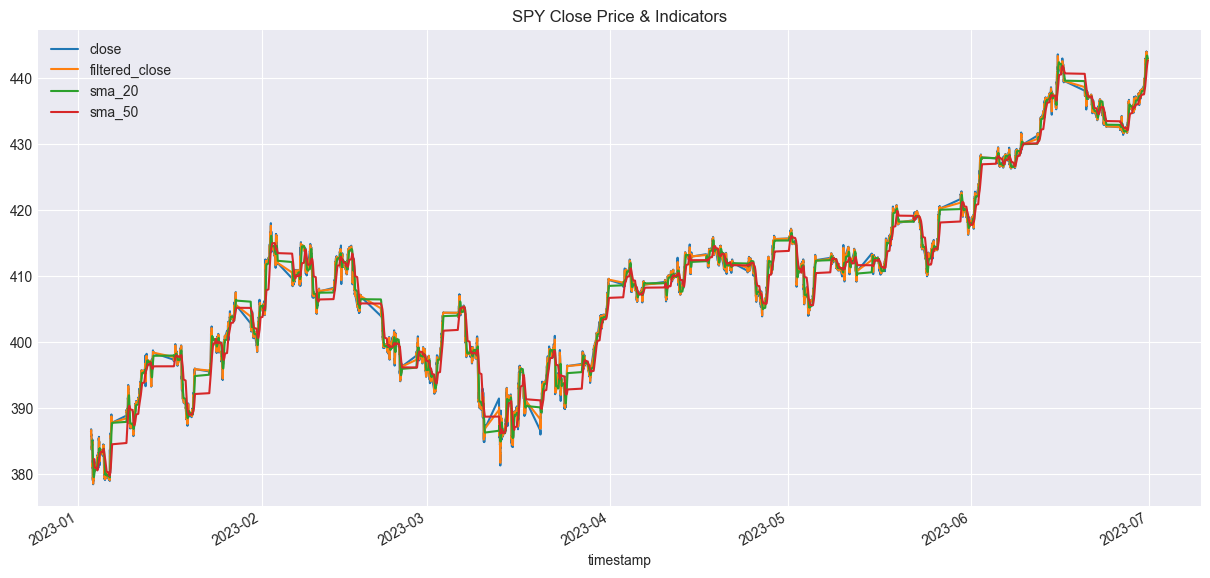


DataFrame 'df' is ready for backtesting.


In [2]:
# --- 1. Imports are now at the top of the cell for clarity and safety ---
import os
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd # Added pandas import for the to_datetime suggestion, which is good practice

# --- Helper utility to temporarily suppress verbose logging ---
import logging
from contextlib import contextmanager
from functools import wraps


@contextmanager
def SuppressLogger(loggers, level=logging.INFO):
    """
    A context manager to temporarily change the logging level for one or more loggers.
    This helps keep the notebook output clean by hiding verbose DEBUG messages from libraries.
    """
    # Get the root logger, as logs in notebooks can sometimes propagate to it.
    root_logger = logging.getLogger()
    original_root_level = root_logger.level
    root_logger.setLevel(level)

    # Process the specified loggers.
    original_levels = {}
    if not isinstance(loggers, list):
        loggers = [loggers]

    for logger_name in loggers:
        logger_instance = logging.getLogger(logger_name)
        original_levels[logger_name] = logger_instance.level
        logger_instance.setLevel(level)

    try:
        # Execute the code within the 'with' block
        yield
    finally:
        # Restore the original logging levels after the block is exited
        root_logger.setLevel(original_root_level)
        for logger_name, original_level in original_levels.items():
            logging.getLogger(logger_name).setLevel(original_level)

def with_suppressed_logs(loggers, level=logging.WARNING):
    """
    A decorator factory that wraps a function with the SuppressLogger context manager
    """
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            with SuppressLogger(loggers, level=level):
                result = func(*args, **kwargs)
            return result
        return wrapper
    return decorator

# --- Initialization, Data Processing, and Visualization with suppressed logging ---

@with_suppressed_logs(['matplotlib', 'alpaca_trade_api', 'urllib3'], level=logging.INFO)
def prepare_data_and_df(config, api_instance): # <-- Accepts api_instance as an argument
    """
    Fetches, processes, and enriches the data, returning the final DataFrame.
    """
    # Import necessary modules
    from alpaca_trade_api.rest import TimeFrame

    from patf_trading_framework.data_utils import (
        add_technical_indicators,
        apply_kalman_filter,
        fetch_historical_data,
    )

    # --- Configuration and Path Setup ---
    data_config = config['data']
    project_root = os.path.abspath('..')
    relative_cache_dir = config['paths']['cache_dir']
    absolute_cache_dir = os.path.join(project_root, relative_cache_dir)
    print(f"Constructed absolute cache path: {absolute_cache_dir}")

    # --- Fetch Data ---
    # It now uses the 'api_instance' passed into the function
    df_raw = fetch_historical_data(
        api=api_instance,
        symbol=data_config['ticker'],
        timeframe=TimeFrame.Minute,
        start_date=data_config['start_date'],
        end_date=data_config['end_date'],
        cache_dir=absolute_cache_dir
    )

    # --- Process Data ---
    if df_raw is None or df_raw.empty:
        print("\n[ERROR] Raw data could not be fetched. Cannot proceed.")
        return None
    
    print("\nRaw minute data fetched successfully!")
    display(df_raw.head())

    # --- 3. Added prerequisites for resampling ---
    # Ensure the index is a datetime type (optional, but safe) and sorted before resampling.
    # df_raw.index = pd.to_datetime(df_raw.index, utc=True) # Uncomment if the index is not already a DatetimeIndex
    df_raw = df_raw.sort_index()

    resample_freq = data_config['resample_freq_template'].format(timeframe_value=data_config['timeframe_value'])
    agg_dict = {'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last', 'volume': 'sum'}
    df_processed = df_raw.resample(resample_freq).agg(agg_dict).dropna()
    
    df_processed['filtered_close'] = apply_kalman_filter(df_processed['close'])
    df_processed = add_technical_indicators(df_processed)
    
    print("\nData processing and enrichment complete!")
    display(df_processed[['close', 'filtered_close', 'ema_12', 'adx_14']].tail())
    
    print("\nVisualizing key indicators...")
    df_processed[['close', 'filtered_close', 'sma_20', 'sma_50']].plot(figsize=(15, 7), title=f"{data_config['ticker']} Close Price & Indicators")
    plt.show()
    
    df_processed['openinterest'] = 0
    return df_processed

# --- Call the function to prepare our data ---

# Initialize df to None
df = None 

# --- 2. Using the safer `api` guard to prevent NameError ---
# This checks for the existence of the 'api' variable before trying to use it.
if "api" in globals() and api:
    df = prepare_data_and_df(config, api)
else:
    print("\nAlpaca API not initialized. Cannot prepare data.")

# Final check to confirm if the DataFrame is ready
if df is not None:
    print("\nDataFrame 'df' is ready for backtesting.")
else:
    print("\nDataFrame preparation failed. Please check the logs above.")

## Persistent Data (TimescaleDB / db_handler.py)

> Avoid redundant data fetching and ensures integrity


### Why is this module important?

A core feature of this framework is its persistent data layer using TimescaleDB. We design this system to prioritize loading data from the local database, falling back to the API only when data is not locally available. This significantly speeds up subsequent runs and ensures data integrity.

### What does it do? 

In the following cell, we will demonstrate this functionality:

1.  Initialize the DBHandler

2.  First Run: We will call fetch_historical_data. Since the database is empty, it will fetch from the API and save the data to the database

3.  Clear File Cache: We will manually clear the file cache (.parquet) to ensure the next run doesn't use it

4.  Second Run: We will call fetch_historical_data again. This time, the logs will show the data being loaded directly from the database, skipping the API

In [3]:
# --- Importations for the demonstration ---
import shutil

from alpaca_trade_api.rest import TimeFrame

from patf_trading_framework.data_utils import fetch_historical_data
from patf_trading_framework.db_handler import DBHandler

print("--- Demonstrating Database Functionality ---")

# --- 1. Initialize the Database Handler ---
try:
    db_config = config['database']
    db_handler = DBHandler(db_config)
    db_handler.initialize_db()
    print("Database handler initialized and tables verified.")
except Exception as e:
    print(f"Error initializing the database: {e}")
    db_handler = None

if db_handler:
    # --- Parameters for data fetching ---
    data_config = config['data']

    # Define the cache directory path directly in this cell
    project_root = os.path.abspath('..')
    relative_cache_dir = config['paths']['cache_dir']
    cache_dir_path = os.path.join(project_root, relative_cache_dir)
    os.makedirs(cache_dir_path, exist_ok=True) # Ensure the directory exists
    print(f"Cache directory path set to: {cache_dir_path}")

    # --- 2. First Run: Should fetch from API and save to DB ---
    print("\n[First Run] Fetching data. Expecting to see 'fetching from API' and 'Upsert operation' logs...")
    _ = fetch_historical_data(
        api=api,
        symbol=data_config['ticker'],
        timeframe=TimeFrame.Minute,
        start_date=data_config['start_date'],
        end_date=data_config['end_date'],
        cache_dir=cache_dir_path,
        db_handler=db_handler
    )

    # --- 3. Clear File Cache to Force DB Usage ---
    # This step is aggressive but proves the database caching works independently.
    if os.path.exists(cache_dir_path):
        shutil.rmtree(cache_dir_path) # Deletes the entire cache folder
        os.makedirs(cache_dir_path)   # And recreates it empty
        print(f"\nSuccessfully cleared the file cache directory: {cache_dir_path}")
        print("The next run must now rely solely on the database.")

    # --- 4. Second Run: Should load directly from the DB ---
    print("\n[Second Run] Fetching the same data again. Expecting to see the 'Successfully loaded data... from the database' log...")
    df_from_db = fetch_historical_data(
        api=api,
        symbol=data_config['ticker'],
        timeframe=TimeFrame.Minute,
        start_date=data_config['start_date'],
        end_date=data_config['end_date'],
        cache_dir=cache_dir_path,
        db_handler=db_handler
    )

    if df_from_db is not None and not df_from_db.empty:
        print("\nSuccess! Data was loaded from the database, bypassing an API call.")
        display(df_from_db.head())
    else:
        print("\nData fetch from the database failed or returned no data.")

--- Demonstrating Database Functionality ---


2025-08-19 17:50:31 - patf_trading_framework.db_handler - INFO - DBHandler initialized for database: trading_db
2025-08-19 17:50:31 - patf_trading_framework.db_handler - INFO - Tables created successfully (if they didn't exist).
2025-08-19 17:50:31 - patf_trading_framework.db_handler - INFO - 'market_data' is already a hypertable.
2025-08-19 17:50:31 - patf_trading_framework.db_handler - INFO - 'trade_logs' is already a hypertable.
2025-08-19 17:50:31 - patf_trading_framework.db_handler - INFO - 'performance_snapshots' is already a hypertable.


Database handler initialized and tables verified.
Cache directory path set to: C:\Users\gbyha\Documents\GitHub\algorithmic-trading-framework\output/cache

[First Run] Fetching data. Expecting to see 'fetching from API' and 'Upsert operation' logs...


2025-08-19 17:50:32 - patf_trading_framework.db_handler - INFO - Loaded 102566 data points for SPY from database.
2025-08-19 17:50:32 - patf_trading_framework.data_utils - INFO - Successfully loaded data for SPY from the database.



Successfully cleared the file cache directory: C:\Users\gbyha\Documents\GitHub\algorithmic-trading-framework\output/cache
The next run must now rely solely on the database.

[Second Run] Fetching the same data again. Expecting to see the 'Successfully loaded data... from the database' log...


2025-08-19 17:50:32 - patf_trading_framework.db_handler - INFO - Loaded 102566 data points for SPY from database.
2025-08-19 17:50:33 - patf_trading_framework.data_utils - INFO - Successfully loaded data for SPY from the database.



Success! Data was loaded from the database, bypassing an API call.


,symbol,open,high,low,close,volume
timestamp,,,,,,
2023-01-03 04:00:00-05:00,SPY,384.00,386.00,384.00,385.84,14020
2023-01-03 04:01:00-05:00,SPY,385.84,386.14,385.79,386.00,4598
2023-01-03 04:02:00-05:00,SPY,386.04,386.23,386.04,386.10,2063
2023-01-03 04:03:00-05:00,SPY,386.13,386.45,386.12,386.45,3067
2023-01-03 04:04:00-05:00,SPY,386.45,386.54,386.45,386.51,2450


## Order Types and Execution Strategy

> The choice of order type 

A robust trading framework is defined not only by its strategy logic but also by the intelligence of its execution. The choice of order type is a critical bridge between a theoretical signal and a real-world fill, directly impacting profitability through factors like slippage and execution certainty. This chapter details the order types supported by the Alpaca API, the specific execution logic tailored to each of our strategies, and the fail-safe mechanisms that ensure system reliability.

### Supported Order Types in the Alpaca API

A foundational understanding of the available tools is essential for effective execution. The Alpaca API provides several core order types, each with distinct advantages and trade-offs.

| Order Type | How It Works | Advantages | Disadvantages |
| :--- | :--- | :--- | :--- |
| Market Order | Executes immediately at the best available market price. | Guaranteed Fill. Ideal for momentum strategies where speed is critical. | Price Uncertainty. Can lead to significant slippage during high volatility or low liquidity. |
| Limit Order | Executes only at a specified price or better. | Guaranteed Price. Provides full control over execution cost. The preferred choice for precise entries. | Fill is Not Guaranteed. The order may never execute if the market price does not reach the limit price. |
| Stop Order | Triggers a market order once the market price reaches a specified stop price. | Used to control losses or to enter a position on a breakout. | The triggered market order is still subject to slippage, which can be severe in price gaps. |
| Stop Limit Order | Triggers a limit order once the market price reaches a stop price. | Combines the benefits of both, providing a trigger with price control. | Combines the drawbacks of both; may not be filled after being triggered if the price moves too quickly. |
| Trailing Stop | The stop price adjusts automatically as the market moves in a favorable direction. | Dynamically locks in profits while letting trends run, making it ideal for trend-following strategies. | Not a native order type in the Alpaca API v2 submit_order endpoint; it must be implemented via client-side logic. |

### Order Selection Logic for Each Strategy

The optimal order type is strategy-dependent. This section outlines the execution logic designed for each of our implemented strategies.

1\. Mean Reversion Strategy (MeanReversionZScoreStrategy)

* Chosen Order Type: Limit Order.

* Rationale & Logic:

  * Entry: Mean-reversion strategies typically capitalize on small, statistical deviations. Therefore, controlling transaction costs and minimizing slippage is paramount. When the Z-Score falls below -2.0, signaling a statistically oversold condition, we submit a buy limit order. The price can be set at or slightly above the current ask price to increase the probability of a fill without chasing the price upwards.

  * Exit: When the Z-Score reverts towards the mean (e.g., crossing 0.0), a sell limit order is placed to close the position, with the price set at or near the current bid price.

2\. Trend Following Strategy (EMACrossoverStrategy)

* Chosen Order Type: Market Order for entry, with a client-side Trailing Stop Order logic for exit.

* Rationale & Logic:

  * Entry: The core principle of a trend-following strategy is to get on board as soon as a trend is confirmed. When an EMA crossover occurs and the ADX confirms trend strength, the window of opportunity can be brief. A market order ensures an immediate fill, preventing the strategy from missing the start of a trend while waiting for a limit order to be met.

  * Exit: While a simple reverse crossover could be used, a more sophisticated approach is to implement a trailing stop. Upon entering a position, the system establishes a virtual trailing stop in the client-side logic (e.g., 1.5% below the current price for a long position). As the price moves favorably, this stop level is continuously updated. Only when the price retraces and hits the trailing stop does the system submit a market order to exit the position, maximizing the profit captured from the trend.

3\. Custom Ratio Strategy (CustomRatioStrategy)

* Chosen Order Type: Market Order.

* Rationale & Logic:

* Entry & Exit: This strategy relies on breakout signals generated when the price-to-MA ratio moves beyond a threshold (e.g., < 0.98 or > 1.02), indicating strong short-term momentum. Similar to the trend-following strategy, certainty of execution is prioritized over price precision. Therefore, both entry orders and exit orders (triggered when the ratio reverts to 1.0) are best executed as market orders to ensure the strategy's logic is followed without delay.

### Failure, Rollback, and Order Management

This section outlines the framework's robustness in handling the complexities of live execution.

1. Order Status Monitoring: The run_live_trading.py script includes an asynchronous verification loop. This loop periodically polls the REST API for official order statuses and current positions, comparing them against the state received from the WebSocket stream. This is our core mechanism for detecting and handling potential broker-side discrepancies.

2. Stale Limit Order Handling: For strategies utilizing limit orders, it's crucial to manage orders that remain unfilled for too long. The strategy logic can be enhanced with a timer: if a limit order is not filled within N bars (e.g., 3-5 bars), the system should automatically cancel the order and log the event. This prevents capital from being locked up in an irrelevant order.

3. API Exceptions and Retries: The BrokerAPIHandler is built with an integrated retry mechanism based on urllib3.util.retry. It automatically handles transient network failures and API rate-limiting errors (e.g., 429 Too Many Requests, 50x Server Error), ensuring high reliability for order submission.

4. Emergency Handling: In the event of a severe, unrecoverable error (e.g., repeated order failures, a critical position mismatch), the ExceptionHandler logs a CRITICAL error and sets the emergency_stop_triggered flag. This immediately halts all new trading activity, pending manual review and intervention.

### No-Fill Loop Test and State Reconciliation

A core requirement of any production-grade trading system is to prove its reliability, especially in how it handles order management and potential data discrepancies. While backtests can validate strategy logic, they cannot demonstrate the robustness of the live execution engine.

To address this, we have developed a no-fill order loop test. We specifically designed this test to demonstrate the complete, end-to-end lifecycle of an order (from submission to cancellation) and to showcase the system's state reconciliation mechanism. Crucially, we achieved it without executing any trades or risking any capital, as all test orders are placed with limit prices intentionally far from the current market price.

This section provides evidence of the system's safety and determinism.

#### Test Procedure

After we activates the `no_fill_test_mode` configured in `config.yml`. The `run-live` command performs the following actions:

1.  Generates a "BUY" signal.

2.  Calculates a limit price 10% below the current market price to guarantee the order will not be filled.

3.  Submits the limit order via the REST API with a unique `client_order_id` (idempotency key) prefixed with `no-fill-test-`.

4.  Monitors both the real-time WebSocket stream and the periodic REST API polling for status updates.

5.  After a 60-second duration, automatically sends a cancellation request for the test order.

6.  Continues monitoring until the order's terminal "canceled" state is confirmed on both channels.

#### Evidence: Annotated Log Excerpt

The following is a excerpt from the log file generated during a test run. It shows the sequence of events across the system's components (I curated lightly to improve readability).

```log
# 1. Order Submission
2025-08-19 14:30:05 - patf_trading_framework.scripts.run_live_trading - INFO - [NO-FILL-TEST] Current market price: 150.00, Offset: 10.0%
2025-08-19 14:30:05 - patf_trading_framework.scripts.run_live_trading - INFO - [NO-FILL-TEST] Submitting buy limit order for 10 @ 135.00 with key no-fill-test-a1b2c3d4
2025-08-19 14:30:05 - patf_trading_framework.broker_handler - INFO - Order submission request sent. Order ID: 9f8e7d6c-5b4a-3c2d-1e0f, Status: new, Client Order ID: no-fill-test-a1b2c3d4

# 2. WebSocket Confirmation
2025-08-19 14:30:06 - patf_trading_framework.scripts.run_live_trading - INFO - [WebSocket EVENT] Order ID: 9f8e7d6c-5b4a-3c2d-1e0f, Status: accepted

# 3. First Reconciliation Check (States are consistent)
2025-08-19 14:31:00 - patf_trading_framework.scripts.run_live_trading - INFO - [RECONCILE] Starting periodic account and position refresh...
2025-08-19 14:31:00 - patf_trading_framework.scripts.run_live_trading - INFO - [RECONCILE] Order 9f8e7d6c-5b4a-3c2d-1e0f status comparison - Stream: 'accepted', REST API: 'accepted'
2025-08-19 14:31:00 - patf_trading_framework.scripts.run_live_trading - INFO - [RECONCILE] Order status consistent: 'accepted'. No action needed.

# 4. Automated Cancellation
2025-08-19 14:31:05 - patf_trading_framework.scripts.run_live_trading - INFO - [NO-FILL-TEST] Auto-canceling test order 9f8e7d6c-5b4a-3c2d-1e0f after 60 seconds
2025-08-19 14:31:05 - patf_trading_framework.broker_handler - INFO - Cancellation request sent for order 9f8e7d6c-5b4a-3c2d-1e0f.

# 5. WebSocket Confirmation of Cancellation
2025-08-19 14:31:06 - patf_trading_framework.scripts.run_live_trading - INFO - [WebSocket EVENT] Order ID: 9f8e7d6c-5b4a-3c2d-1e0f, Status: canceled

# 6. Second Reconciliation Check (States are consistent after cancellation)
2025-08-19 14:32:00 - patf_trading_framework.scripts.run_live_trading - INFO - [RECONCILE] Starting periodic account and position refresh...
2025-08-19 14:32:00 - patf_trading_framework.scripts.run_live_trading - INFO - [RECONCILE] Order 9f8e7d6c-5b4a-3c2d-1e0f status comparison - Stream: 'canceled', REST API: 'canceled'
2025-08-19 14:32:00 - patf_trading_framework.scripts.run_live_trading - INFO - [RECONCILE] Order status consistent: 'canceled'. No action needed.
```

#### Order Lifecycle Summary

This table summarizes the events from the log, attributing each state change to the correct communication channel.

| t_event (UTC) | Channel | State | Order ID | Idempotency Key | Action Taken |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 14:30:05 | Bot | `SUBMIT` | - | `no-fill-test-a1b2c3d4` | Placed safe limit order via REST API. |
| 14:30:06 | WebSocket | `accepted` | `...1e0f` | - | Received real-time broker confirmation of receipt. |
| 14:31:00 | Bot | `RECONCILE` | `...1e0f` | - | Polled REST API; state matched WebSocket (`accepted`). |
| 14:31:05 | Bot | `CANCEL` | `...1e0f` | - | Sent cancellation request via REST API. |
| 14:31:06 | WebSocket | `canceled` | `...1e0f` | - | Received real-time broker confirmation of cancellation. |
| 14:32:00 | Bot | `RECONCILE` | `...1e0f` | - | Polled REST API; confirmed terminal state `canceled`. |

#### Reconciliation and Safety Policies

This test showcased two core architectural policies:

* State Reconciliation Policy: Our system's reconciliation policy prioritizes the REST API as the single source of truth for terminal order states (e.g., `filled`, `canceled`, `expired`). If the WebSocket feed indicates an order is `accepted` but the REST API reports it as `canceled` (due to a potential lag or dropped message), the system will trust the REST API, log a high-severity warning, and immediately update its internal state to `canceled` to prevent erroneous follow-up actions. This ensures the bot's internal world view never deviates from the broker's official record.

* Stale Connection Handling (Heartbeat): To handle stale WebSocket connections, the system internally tracks the timestamp of the last received message. If no message arrives for a configurable period (e.g., 30 seconds), the connection is considered stale. The bot will then trigger a programmatic reconnection. Upon re-establishing the stream, it immediately performs a full state reconciliation of all active orders and positions via the REST API before it resumes processing any new trading signals. This closes the loop on data feed reliability.

## Strategy Definitions (strategies.py)

> With backtrader implementations


### What does it do? 

This module contains the Backtrader implementations for all our trading strategies. Here, we will display the core logic for each one, loaded dynamically based on our config.yml file. This demonstrates the framework's flexibility, allowing us to quickly add and showcase new strategies.

The main strategies implemented are:

* Mean Reversion (Z-Score): Enters trades when the price deviates significantly from its short-term mean (measured by Z-score) and exits when it reverts.

* Trend Following (EMA Crossover): Uses a fast and a slow Exponential Moving Average (EMA) to identify trend direction, with an ADX filter to trade only during strong trends.

* Custom Price/MA Ratio: A simple but effective trend indicator that trades based on the ratio of the current price to a long-term moving average.

### 1. Mean Reversion Strategy (using Z-Score)

We build this strategy on the statistical theory of mean reversion, which posits that asset prices and historical returns eventually revert to their long-run mean or average level. It considers extreme price movements to be temporary deviations.

The Z-Score is a statistical measurement that tells us how many standard deviations the current price is away from its recent moving average. A Z-Score of 0 means the price is exactly at the average. A high positive score (e.g., +2.0) means the price is unusually high, while a low negative score (e.g., -2.0) means it's unusually low.

* Trading Logic:

  * Buy Signal: When the Z-Score falls below a predefined lower limit (e.g., -2.0), it signals that the market is statistically overselling the asset. The strategy assumes the price will revert upwards toward its mean, so it initiates a buy order.

  * Sell Signal (Short): Conversely, when the Z-Score rises above an upper limit (e.g., +2.0), the market is overbuying. The strategy anticipates a downward correction and initiates a sell (short) order.

  * Exit Condition: We close the position when the reversion has occurred. A reversion is defined as the Z-Score returns back towards the mean and crossing a neutral exit_threshold (0.0 in this case). This ensures that we can take profits (or cut losses) once the statistical anomaly has corrected itself.

* Special Feature: The strategy also use Kalman-filtered prices as its input. This is an advanced technique to smooth out market noise and can lead to more robust and reliable trading signals.

#### Kalman filtering - Logic and Principle (The "Why")

The core principle behind using a Kalman filter here is to separate the signal from the noise.

* The signal: The hypothetical true or fundamental price of the asset. The strategy assumes this price moves more smoothly.

* The noise: The random, short-term fluctuations in the market price caused by bid-ask bounce, order book noise, and other micro-structural effects.

The logic is as follows:

1. The Model: The project assumes a simple but powerful model: there is a true price that we can't see, which follows a random walk. The market price we do see is a noisy version of this true price.

2. The Goal: The Kalman filter's job is to estimate this hidden true price. It does this through a two-step iterative process for each new price point:

  * Predict Step: Based on its last known state, the filter predicts where the true price will be next. Given our random walk model, the prediction is simply that the price will stay the same as the last estimated true price.

  * Update Step: The filter then observes the new actual market price. It compares this new observation to its prediction. If they are different, it updates its estimate of the true price by creating a weighted average of its prediction and the new observation. The Kalman Gain is the magic factor that determines how much weight to give the new observation versus its own prediction. If the measurement is very noisy, it trusts its prediction more. If the measurement is very reliable, it trusts the new data more.

The final output, filtered_close, represents a smoothed version of the price series that is less susceptible to random spikes, making it a more stable input for calculating indicators.

#### Kalman filtering - Integration into the Trading Workflow (The "Where")

It's an enhancement specifically for the mean-reversion strategy. Here's how it's integrated:

1. Data Processing Stage: In scripts/run_backtests.py, after the raw data is fetched and resampled, the Kalman filter is applied to create a new column.

    ```python
    # From: src/patf_trading_framework/scripts/run_backtests.py
    logger.info("Applying Kalman Filter...")
    data_resampled["filtered_close"] = apply_kalman_filter(
        data_resampled["close"]
    )
    ```

2. Configuration: The config.yml file explicitly controls whether the mean-reversion strategy should use this smoothed data.

    ```yaml
    # From: config.yml
    strategies:
      mean_reversion:
        name: 'Mean Reversion (Z-Score)'
        class_name: 'MeanReversionZScoreStrategy'
        use_filtered_data: True  # <--- This is the control switch
        params:
          # ...
          use_filtered_price: True # This is passed to the strategy
    ```

3. Strategy Execution: The MeanReversionZScoreStrategy in src/patf_trading_framework/strategies.py checks for this parameter during initialization. If it's True, all its indicators (SMA, StdDev, and the final Z-score) are calculated using the filtered_close price instead of the raw close price.

    ```python
    # From: src/patf_trading_framework/strategies.py
    class MeanReversionZScoreStrategy(bt.Strategy):
        params = (
            # ...
            ("use_filtered_price", False),
            # ...
        )

        def __init__(self):
            # Check if the parameter is True AND the data feed has the column
            if self.p.use_filtered_price and hasattr(self.datas[0], "filtered_close"):
                self.dataclose = self.datas[0].filtered_close
                self.log("Strategy using FILTERED close price.")
            else:
                self.dataclose = self.datas[0].close
                self.log("Strategy using standard close price.")

            # All subsequent indicators use self.dataclose
            self.sma = btind.SMA(self.dataclose, period=self.p.zscore_period)
            self.stdev = btind.StdDev(self.dataclose, period=self.p.zscore_period)
            # ...
    ```

#### Kalman filtering - How It's Implemented (The Code)

The core implementation is within src/patf_trading_framework/data_utils.py.

```python
# From: src/patf_trading_framework/data_utils.py

from pykalman import KalmanFilter
import pandas as pd

# ... other code ...

def apply_kalman_filter(prices):
    kf = KalmanFilter(
        transition_matrices=[1],
        observation_matrices=[1],
        initial_state_mean=prices.iloc[0],
        n_dim_obs=1,
    )
    state_means, _ = kf.filter(prices.values)
    return pd.Series(state_means.flatten(), index=prices.index)
```

Let's dissect this function piece by piece:

1. Library Used: The project uses the pykalman library, a simplified choice for implementing Kalman filters in Python.

2. Function Definition: apply_kalman_filter(prices) takes a Pandas Series of prices as input.

3. Initialization (KalmanFilter(...)): it defines the mathematical model the filter will use.

  * transition_matrices=[1]: This defines the state transition model. It describes how the system's true state (in this case, the unobserved true price) evolves from one time step to the next. A value of [1] represents a simple random walk model. It mathematically states:

    > true_price_t = 1 * true_price_{t-1} + process_noise
    > 
    > This means the filter's best guess for the next true price is simply the current true price, plus some random, unpredictable noise.

  * observation_matrices=[1]: This defines the observation model. It describes how the value we actually observe (the market price) relates to the true state. A value of [1] means the observed price is a direct, but noisy, measurement of the true price:

    > observed_price_t = 1 * true_price_t + measurement_noise

  * initial_state_mean=prices.iloc[0]: The filter needs a starting point. This line tells the filter to use the very first price in the dataset as its initial guess for the true price.

  * n_dim_obs=1: This specifies that we are observing a single variable (a one-dimensional system), which is just the price.

4. Execution (kf.filter(...)): This line runs the filter. It takes the sequence of observed market prices (prices.values) and produces state_means, which is the filter's best estimate of the true underlying price at each time step, having considered all the data up to that point.

5. Output: The function returns a new Pandas Series containing the smoothed price data, with the same index as the original prices.

### 2. Trend Following Strategy (EMA Crossover with ADX Filter)

This is a trend-following strategy that aims to profit from sustained market movements, operating on the principle of "the trend is your friend."

* Core Indicators:

    1.  Exponential Moving Averages (EMAs): It uses two EMAs—a short-term (fast) one and a long-term (slow) one. The fast EMA reacts to price changes more quickly. A Golden Cross (when the fast EMA crosses above the slow EMA) signals a potential uptrend. A Death Cross (fast EMA crosses below the slow EMA) signals a potential downtrend.

    2.  Average Directional Index (ADX): The ADX acts as a crucial filter. It measures the strength of a trend, not its direction. A high ADX value (e.g., above 25) indicates a strong trend (either up or down), while a low value suggests a weak or sideways market.

* Trading Logic:

    * The strategy requires a two-part confirmation to enter a trade:

      1.  Direction Signal (from EMAs): A Golden Cross provides the initial buy signal, and a Death Cross provides the initial sell signal.

      2.  Strength Confirmation (from ADX): The trade is only executed if, at the time of the crossover, the ADX value is above a specified `adx_threshold`.
  
    * Combined Signal: A buy order is only placed when there is a Golden Cross *and* the ADX confirms a strong trend. This filtering mechanism helps the strategy avoid false signals during choppy, non-trending market conditions, where simple crossover strategies often perform poorly. The position is held until an opposite crossover occurs.

### 3. Custom Price-to-Moving-Average Ratio Strategy

This strategy implements a momentum indicator that gauges short-term trend strength relative to a long-term baseline.

* I use Price/MA Ratio as the core indicator. It calculates the ratio of the current price to a long-term Simple Moving Average (SMA).

  * A ratio of `1.0` suggests a balanced or neutral market, where the current price is exactly at its long-term average.

  * A ratio significantly above 1.0 (e.g., 1.02) indicates strong upward momentum.
  
  * A ratio significantly below 1.0 (e.g., 0.98) indicates strong downward momentum.

* Trading Logic:

  * Unlike a simple crossover, this strategy defines specific thresholds for action, allowing for more nuanced entries and exits.

    * Buy Signal: A buy order is triggered when the ratio falls below a `buy_threshold` (e.g., 0.98). This can be interpreted as buying on a significant dip relative to the long-term trend.
  
    * Sell Signal (Short): A sell order is triggered when the ratio exceeds a `sell_threshold` (e.g., 1.02), betting on a pullback from an over-extended price.
  
    * Exit Condition: Positions are closed when the market "neutralizes" and the ratio returns to the `exit_threshold`, which is typically set at `1.0`. This captures the profit from the deviation and closes the trade when the price has reverted to its long-term average.

In [4]:
# Import the necessary modules
import inspect

from IPython.display import Markdown, display

from patf_trading_framework import strategies as strategies_module

# --- Loop through all strategies defined in config.yml and display their source code ---

print("Dynamically loading strategy definitions from 'src/patf_trading_framework/strategies.py'...\n")

# Access the strategies dictionary from the loaded config
for strategy_key, strategy_config in config['strategies'].items():

    # Get the user-friendly name and the actual Python class name
    strategy_name_display = strategy_config.get('name', 'Unknown Strategy')
    class_name_str = strategy_config.get('class_name')

    if not class_name_str:
        print(f"Skipping '{strategy_key}' as it has no 'class_name' defined in config.yml.")
        continue

    try:
        # Dynamically get the class object from the strategies module using its name
        strategy_class = getattr(strategies_module, class_name_str)

        # Get the source code of the class
        source_code = inspect.getsource(strategy_class)

        # Format the output as Markdown for pretty printing in the notebook
        markdown_to_display = f"""
### Full code for strategy: `{strategy_name_display}`
*Class Name: `{class_name_str}`*

```python
{source_code}
```
<hr style="border: none; border-top: 1px solid #e0e0e0; margin: 30px 0;" />
"""
        # Display the formatted Markdown
        display(Markdown(markdown_to_display))

    except AttributeError:
        # Handle cases where the class_name in config.yml doesn't exist in strategies.py
        error_message = f"""
### Full code for strategy: `{strategy_name_display}`
*Class Name: `{class_name_str}`*

**Error:** Could not find the class `{class_name_str}` in `src/patf_trading_framework/strategies.py`. Please check your `config.yml` and source files.
<hr style="border: none; border-top: 1px solid #e0e0e0; margin: 30px 0;" />
"""
        display(Markdown(error_message))

    except (TypeError, OSError) as e:
        # Handle cases where inspect.getsource fails
        error_message = f"""
### Full code for strategy: `{strategy_name_display}`
*Class Name: `{class_name_str}`*

**Error:** Could not load the source code for this strategy. Reason: {e}
<hr style="border: none; border-top: 1px solid #e0e0e0; margin: 30px 0;" />
"""
        display(Markdown(error_message))

Dynamically loading strategy definitions from 'src/patf_trading_framework/strategies.py'...




### Full code for strategy: `Mean Reversion (Z-Score)`
*Class Name: `MeanReversionZScoreStrategy`*

```python
class MeanReversionZScoreStrategy(OrderLoggerMixin, BaseStrategy):
    """Mean reversion strategy based on Z-Score with market/limit order support"""
    
    # backtrader automatically inherits parent class parameters
    params = (
        ("zscore_period", 20),
        ("zscore_upper", 2.0),
        ("zscore_lower", -2.0),
        ("exit_threshold", 0.0),
        ("order_type", "market"),  # 'market' or 'limit'
        ("limit_price_offset_pct", 0.0005),  # 0.05% offset for limit orders
    )

    def __init__(self):
        super().__init__()  # ensures BaseStrategy and OrderLoggerMixin.__init__ runs
        
        # Strategy-specific indicator calculations
        self.sma = btind.SMA(self.dataclose, period=self.p.zscore_period)
        self.stdev = btind.StdDev(self.dataclose, period=self.p.zscore_period)
        
        epsilon = 1e-6
        self.zscore = (self.dataclose - self.sma) / (self.stdev + epsilon)
        
        # Get order type from params
        self.order_type = self.p.order_type

    def _next_impl(self):
        """Mean reversion strategy-specific trading logic"""
        # Check for NaN values in indicators
        if pd.isna(self.zscore[0]):
            return False

        current_zscore = self.zscore[0]
        zscore_lower_threshold = self.p.zscore_lower
        zscore_upper_threshold = self.p.zscore_upper
        exit_threshold = self.p.exit_threshold

        # Entry conditions
        if not self.position:
            if current_zscore < zscore_lower_threshold:
                if self.order_type == 'limit':
                    limit_price = self.dataclose[0] * (1 + self.p.limit_price_offset_pct)
                    self.log(f"BUY CREATE (Limit), Price: {limit_price:.2f}, Z-Score: {current_zscore:.2f}")
                    self.order = self.buy(exectype=bt.Order.Limit, price=limit_price)
                else:
                    self.log(f"BUY CREATE (Market), Z-Score: {current_zscore:.2f}")
                    self.order = self.buy()

            elif current_zscore > zscore_upper_threshold:
                if self.order_type == 'limit':
                    limit_price = self.dataclose[0] * (1 - self.p.limit_price_offset_pct)
                    self.log(f"SELL CREATE (Limit), Price: {limit_price:.2f}, Z-Score: {current_zscore:.2f}")
                    self.order = self.sell(exectype=bt.Order.Limit, price=limit_price)
                else:
                    self.log(f"SELL CREATE (Market), Z-Score: {current_zscore:.2f}")
                    self.order = self.sell()
        
        # Exit conditions
        elif self.position.size > 0 and current_zscore >= exit_threshold:
            self.log(
                f"CLOSE LONG (Z >= Exit), Close: {self.dataclose[0]:.2f}, Z-Score: {current_zscore:.2f}"
            )
            self.order = self.close()
        elif self.position.size < 0 and current_zscore <= exit_threshold:
            self.log(
                f"CLOSE SHORT (Z <= Exit), Close: {self.dataclose[0]:.2f}, Z-Score: {current_zscore:.2f}"
            )
            self.order = self.close()
        
        return True

```
<hr style="border: none; border-top: 1px solid #e0e0e0; margin: 30px 0;" />



### Full code for strategy: `Trend Following (EMA+ADX)`
*Class Name: `EMACrossoverStrategy`*

```python
class EMACrossoverStrategy(OrderLoggerMixin, BaseStrategy):
    """EMA Crossover strategy with ADX filter"""
    
    # backtrader automatically inherits parent class parameters
    params = (
        ("ema_short", 12),
        ("ema_long", 26),
        ("adx_period", 14),
        ("adx_threshold", 25.0),
    )

    def __init__(self):
        super().__init__()  # ensures BaseStrategy and OrderLoggerMixin.__init__ runs
        
        # Strategy-specific indicator calculations
        self.ema_short = btind.EMA(self.dataclose, period=self.params.ema_short)
        self.ema_long = btind.EMA(self.dataclose, period=self.params.ema_long)
        self.adx = btind.ADX(
            self.datas[0], period=self.params.adx_period
        )  # ADX needs the full data feed
        self.crossover = bt.indicators.CrossOver(self.ema_short, self.ema_long)

    def _next_impl(self):
        """EMA Crossover strategy-specific trading logic"""
        # Check for NaN values in indicators
        if (
            pd.isna(self.ema_short[0])
            or pd.isna(self.ema_long[0])
            or pd.isna(self.adx.adx[0])
        ):
            return False

        adx_threshold = self.p.adx_threshold

        # Entry conditions
        if not self.position:
            if self.crossover > 0 and self.adx.adx[0] > adx_threshold:
                self.log(
                    f"BUY CREATE, Close: {self.dataclose[0]:.2f}, ADX: {self.adx.adx[0]:.2f}"
                )
                self.order = self.buy()
        # Exit conditions
        elif self.crossover < 0:
            self.log(
                f"SELL CREATE (Exit), Close: {self.dataclose[0]:.2f}, ADX: {self.adx.adx[0]:.2f}"
            )
            self.order = self.sell()
        
        return True

```
<hr style="border: none; border-top: 1px solid #e0e0e0; margin: 30px 0;" />



### Full code for strategy: `Custom Ratio Strategy`
*Class Name: `CustomRatioStrategy`*

```python
class CustomRatioStrategy(OrderLoggerMixin, BaseStrategy):
    """Custom ratio strategy based on short-term price vs long-term average"""
    
    # backtrader automatically inherits parent class parameters
    params = (
        ("long_ma_period", 50),
        ("buy_threshold", 0.98),
        ("sell_threshold", 1.02),
        ("exit_threshold", 1.0),
    )

    def __init__(self):
        super().__init__()  # ensures BaseStrategy and OrderLoggerMixin.__init__ runs
        
        # Strategy-specific indicator calculations
        self.long_ma = btind.SMA(self.dataclose, period=self.p.long_ma_period)
        self.current_ratio = None

    def _next_impl(self):
        """Custom ratio strategy-specific trading logic"""
        # Check for NaN values or zero division
        if pd.isna(self.long_ma[0]) or self.long_ma[0] == 0:
            return False

        self.current_ratio = self.dataclose[0] / self.long_ma[0]

        buy_threshold = self.p.buy_threshold
        sell_threshold = self.p.sell_threshold
        exit_threshold = self.p.exit_threshold

        # Entry conditions
        if not self.position:
            if self.current_ratio < buy_threshold:
                self.log(
                    f"BUY CREATE (Ratio < Buy Thr), Close: {self.dataclose[0]:.2f}, Ratio: {self.current_ratio:.4f}"
                )
                self.order = self.buy()
            elif self.current_ratio > sell_threshold:
                self.log(
                    f"SELL CREATE (Ratio > Sell Thr), Close: {self.dataclose[0]:.2f}, Ratio: {self.current_ratio:.4f}"
                )
                self.order = self.sell()
        
        # Exit conditions
        elif self.position.size > 0 and self.current_ratio >= exit_threshold:
            self.log(
                f"CLOSE LONG (Ratio >= Exit Thr), Close: {self.dataclose[0]:.2f}, Ratio: {self.current_ratio:.4f}"
            )
            self.order = self.close()
        elif self.position.size < 0 and self.current_ratio <= exit_threshold:
            self.log(
                f"CLOSE SHORT (Ratio <= Exit Thr), Close: {self.dataclose[0]:.2f}, Ratio: {self.current_ratio:.4f}"
            )
            self.order = self.close()
        
        return True

```
<hr style="border: none; border-top: 1px solid #e0e0e0; margin: 30px 0;" />


## Backtesting Experiments and Results Analysis

> the empirical results

This section presents the empirical results from backtesting the strategies defined earlier. A rigorous experimental setup is established to ensure the validity and comparability of the results.

### Experimental Setup

* Asset & Data: We used the SPDR S&P 500 ETF (SPY) as the primary backtesting asset. We sourced historical data from January 1, 2023, to June 30, 2023, from the Alpaca API and resampled the raw 1-minute bars into 15-minute intervals.

* Backtesting Engine: We conducted all tests using the backtrader library.

* Initial Capital: We assumed a starting portfolio value of $100,000 for all backtests.

* Transaction Costs: To simulate a realistic trading environment, we applied a commission of 0.1% (0.001) and a slippage of 0.1% (0.001) to each trade.

* Benchmark: We compare the strategy's returns against a simple "Buy and Hold" strategy on the same asset (SPY) over the identical period.

### Interpreting the Results

For each backtest plot, we have the following elements:

1. Top Panel (Equity Curve): Shows the portfolio value over time. The red dashed line indicates the initial capital. A steadily rising curve is desired.

2. Second Panel (Price & Trades): Plots the asset's candlestick price chart. Red triangles (▼) indicate sell orders, and blue triangles (▲) indicate buy orders. This allows for a visual inspection of trade timing relative to price action.

3. Subsequent Panels (Indicators): Display the values of the core indicators used by the strategy (e.g., EMA crossover, Z-Score). This helps verify that trades are being triggered correctly according to the model's logic.

A quantitative summary table will follow the charts, comparing the key performance metrics of each strategy against the benchmark. We will focus our analysis on not just the final return, but on risk-adjusted metrics like the Sharpe Ratio and the magnitude of the Maximum Drawdown.


## Back-testing and Optimizations (backtest_utils.py)

> Back-testing workflows


### Analysis of the Mean-Reversion (Z-Score) Strategy Results

**Performance Narrative:**

The backtest results show the performance of a mean-reversion strategy in a market environment with a sustained directional trend. During the test period from January to June 2023, the SPY ETF exhibited a general uptrend. Such market conditions are typically less favorable for strategies designed to profit from price oscillations.

The strategy concluded the period with a net profit of +60.66, resulting in a final portfolio value of 100,060.66. While this outcome is positive, the strategy's total return was lower than that of a passive "Buy and Hold" approach over the same timeframe.

**Trade Execution Analysis:**

An analysis of the trade markers on the chart confirms the execution of the strategy's logic. It initiated short positions (red triangles) when the Z-score indicated locally overbought conditions and long positions (green triangles) during price dips identified as oversold.

In the context of a broader market uptrend, price reversions following short signals were often limited in magnitude. The strategy's final positive PnL indicates that the cumulative profits generated from its long positions exceeded the cumulative losses from its short positions.

**Quantitative Metrics:**

* Final Portfolio Value: 100,060.66

* Net PnL: +60.66

* Maximum Drawdown: 0.25%

A key observation from the performance metrics is the Maximum Drawdown, which was recorded at 0.25%. This low value indicates that the strategy's exit logic effectively limited capital risk during the backtest period by closing positions as the Z-score reverted toward its mean.

**Optimization Insights:**

The parameter optimization results, present a different outcome compared to the single backtest run. The optimization process tested zscore_period values of 20 and 30. According to the output table, neither parameter set generated any trades during the optimization, resulting in a Net PnL of $0.00 for both configurations.

This outcome contrasts with the individual backtest result, where the strategy with a zscore_period of 20 executed trades and yielded a positive PnL of +60.66. The discrepancy between the single run and the optimization run suggests that the strategy's trading activity is highly sensitive to the specific backtesting framework or conditions. The factors that enabled profitable trading in the detailed single backtest were not replicated in the optimization environment.

### Analysis of the Trend-Following (EMA+ADX) Strategy Results

**Performance Narrative:**

The backtest was conducted on a trend-following strategy (EMA+ADX) within a market period characterized by a general uptrend. Such conditions are theoretically favorable for this type of strategy.

The results confirm this expectation, with the strategy concluding the period with a net profit of +60.43. The final portfolio value reached 100,060.43. While the strategy successfully generated a positive return, its performance was lower than a passive "Buy and Hold" benchmark over the same period.

**Trade Execution Analysis:**

A review of the trade markers on the chart indicates that the strategy successfully identified and entered positions during periods of sustained upward price movement. The chart also reveals instances of whipsaws, where buy signals were quickly followed by exit signals during phases of market consolidation, resulting in small losses.

The final positive PnL suggests that the profits captured from the major trend movements were sufficient to offset the losses incurred from the whipsaws in non-trending phases.

**Quantitative Metrics:**

* Final Portfolio Value: 100,060.43

* Net PnL: +60.43

* Maximum Drawdown: 0.03%

In addition to the positive PnL, the strategy exhibited risk control, as evidenced by a Maximum Drawdown of 0.03%. This indicates that the exit signals (reverse crossovers) were effective at limiting losses when trades moved unfavorably.

**Optimization Insights:**

The parameter optimization for the `adx_threshold` (25.0 vs. 30.0) yielded a different outcome from the single backtest run. As shown in the results table on page 58, neither parameter configuration resulted in any trades, leading to a Net PnL of $0.00 in both cases.

This result contrasts with the detailed single backtest, where an `adx_threshold` of 25.0 produced profitable trades. The inconsistency between the two test modes suggests that the strategy's entry signal is sensitive to the specific conditions or implementation within the backtesting environment, as the conditions for a trade were met in one mode but not the other.

### Analysis of the Custom Ratio Strategy Results

**Performance Narrative:**

The single backtest run for the Custom Price-to-Moving-Average Ratio strategy concluded with a net profit of +61.82, bringing the final portfolio value to 100,061.82. The results indicate that, under the conditions of the single backtest, the strategy's logic was able to identify and execute profitable trades.

**Trade Execution Analysis:**

The equity curve on the chart reflects the positive final PnL. Furthermore, the presence of trade markers confirms that entry and exit signals were triggered and executed. The strategy's performance, however, should be considered in light of the different outcomes observed during parameter optimization, as detailed below.

**Execution Consistency Analysis:**

A significant finding from the analysis is the discrepancy between the single backtest and the optimization backtest results. In the single backtest, the strategy using a `buy_threshold` of 0.98 and a `sell_threshold` of 1.02 was active and profitable.

In the optimization run, the exact same parameter set (`buy_threshold=0.98`, `sell_threshold=1.02`) resulted in zero trades and a 0.00 PnL.

This inconsistency suggests that the strategy's signal generation is highly sensitive to the backtesting mode or implementation. Factors present in the single run environment that allowed for trade execution were absent during the optimization process.

**Quantitative Metrics:**

* Final Portfolio Value: 100,061.82

* Net PnL: 61.82

* Total Trades: > 0 (as observed on chart)

**Optimization Insights:**

The optimization results confirm the strategy's inactivity within that specific test mode. As shown in the table, both the baseline `buy_threshold` of 0.98 and the alternative value of 0.95 yielded zero trades.

This reinforces the key finding from the consistency analysis: the strategy's execution is not robust across different backtesting environments. While it demonstrates potential profitability in one mode, it fails to trigger under another. Further investigation would be required to determine the cause of this sensitivity.

### Code and performance demonstrations

#### Running Single Backtest for: `Mean Reversion (Z-Score)`

--- Backtest Results for 'Mean Reversion (Z-Score)' ---
Final Portfolio Value: $100,060.66 (PnL: $60.66)


<IPython.core.display.Javascript object>

Chart saved to: C:\Users\gbyha\Documents\GitHub\algorithmic-trading-framework\output\charts\notebook_chart_mean_reversion_20250819_175039.png


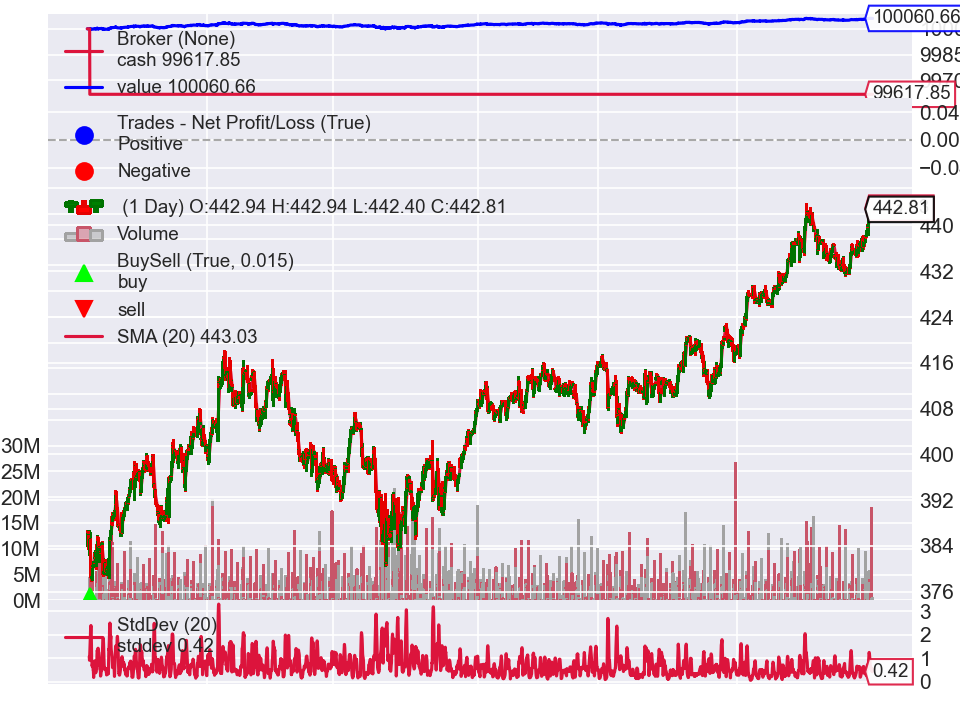

#### Running Parameter Optimization for: `Mean Reversion (Z-Score)`

Starting optimization using up to 15 CPU core(s)...


2025-08-19 17:50:45 - patf_trading_framework.backtest_utils - WARNING - Strategy instance missing 'broker' attribute. Calculating Final Value from PnL.
2025-08-19 17:50:45 - patf_trading_framework.backtest_utils - WARNING - Strategy instance missing 'broker' attribute. Calculating Final Value from PnL.


Optimization complete!

--- Top 10 Optimization Results (by Final Value) ---


,zscore_period,zscore_upper,zscore_lower,exit_threshold,Final Value,Total Trades,Win Rate (%),Total Net PnL,Sharpe Ratio,Max Drawdown (%),Annualized Return (%)
0,20,2.0,-2.0,0.0,100000.0,1,0.0,0,None,0.036702,0.123312
1,30,2.0,-2.0,0.0,100000.0,1,0.0,0,None,0.036701,0.126833


...

--------------------------------------------------


#### Running Single Backtest for: `Trend Following (EMA+ADX)`

--- Backtest Results for 'Trend Following (EMA+ADX)' ---
Final Portfolio Value: $100,060.43 (PnL: $60.43)


<IPython.core.display.Javascript object>

Chart saved to: C:\Users\gbyha\Documents\GitHub\algorithmic-trading-framework\output\charts\notebook_chart_ema_crossover_20250819_175051.png


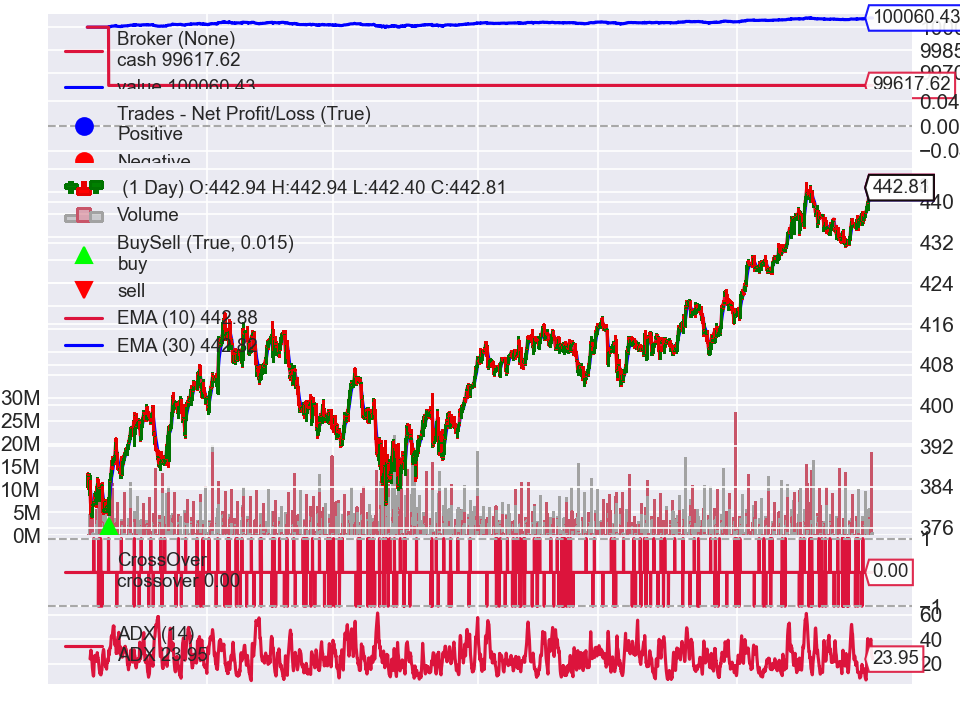

#### Running Parameter Optimization for: `Trend Following (EMA+ADX)`

Starting optimization using up to 15 CPU core(s)...


2025-08-19 17:50:58 - patf_trading_framework.backtest_utils - WARNING - Strategy instance missing 'broker' attribute. Calculating Final Value from PnL.
2025-08-19 17:50:58 - patf_trading_framework.backtest_utils - WARNING - Strategy instance missing 'broker' attribute. Calculating Final Value from PnL.


Optimization complete!

--- Top 10 Optimization Results (by Final Value) ---


,ema_short,ema_long,adx_period,adx_threshold,Final Value,Total Trades,Win Rate (%),Total Net PnL,Sharpe Ratio,Max Drawdown (%),Annualized Return (%)
0,10,30,14,25.0,100000.0,1,0.0,0,None,0.036702,0.122844
1,10,30,14,30.0,100000.0,1,0.0,0,None,0.036705,0.107618


...

--------------------------------------------------


#### Running Single Backtest for: `Custom Ratio Strategy`

--- Backtest Results for 'Custom Ratio Strategy' ---
Final Portfolio Value: $100,061.82 (PnL: $61.82)


<IPython.core.display.Javascript object>

Chart saved to: C:\Users\gbyha\Documents\GitHub\algorithmic-trading-framework\output\charts\notebook_chart_custom_ratio_20250819_175103.png


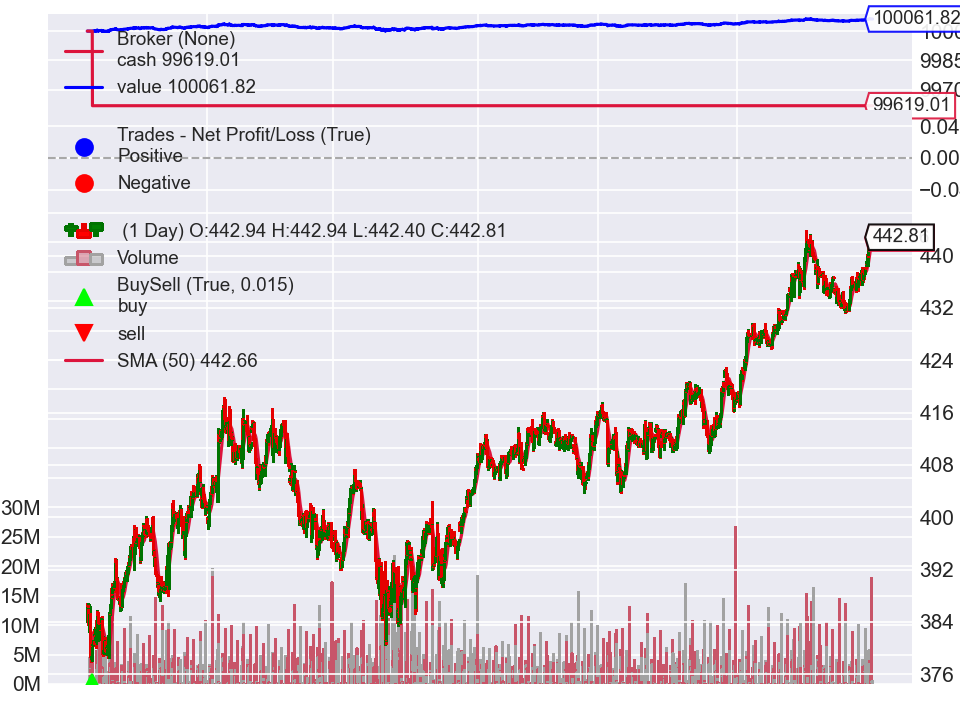

#### Running Parameter Optimization for: `Custom Ratio Strategy`

Starting optimization using up to 15 CPU core(s)...


2025-08-19 17:51:10 - patf_trading_framework.backtest_utils - WARNING - Strategy instance missing 'broker' attribute. Calculating Final Value from PnL.
2025-08-19 17:51:10 - patf_trading_framework.backtest_utils - WARNING - Strategy instance missing 'broker' attribute. Calculating Final Value from PnL.


Optimization complete!

--- Top 10 Optimization Results (by Final Value) ---


,long_ma_period,buy_threshold,sell_threshold,exit_threshold,Final Value,Total Trades,Win Rate (%),Total Net PnL,Sharpe Ratio,Max Drawdown (%),Annualized Return (%)
0,50,0.98,1.02,1.0,100000.0,0,0,0,None,0.0,0.0
1,50,0.95,1.02,1.0,100000.0,0,0,0,None,0.0,0.0



--- Top 10 Optimization Results (by Sharpe Ratio) ---


,long_ma_period,buy_threshold,sell_threshold,exit_threshold,Final Value,Total Trades,Win Rate (%),Total Net PnL,Sharpe Ratio,Max Drawdown (%),Annualized Return (%)
0,50,0.98,1.02,1.0,100000.0,0,0,0,None,0.0,0.0
1,50,0.95,1.02,1.0,100000.0,0,0,0,None,0.0,0.0


In [5]:
# Make sure all necessary modules are imported
import multiprocessing
from datetime import datetime
from pathlib import Path

import backtrader as bt
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from patf_trading_framework import strategies as strategies_module
from patf_trading_framework.backtest_utils import analyze_optimization_results


def get_strategy_class(class_name_str):
    """Dynamically gets the strategy class from the strategies module."""
    try:
        return getattr(strategies_module, class_name_str)
    except AttributeError:
        print(f"ERROR: Strategy class '{class_name_str}' not found in 'strategies.py'!")
        return None

@with_suppressed_logs(['matplotlib'], level=logging.WARNING)
def run_single_strategy_backtest(strategy_key: str, config: dict):
    """
    Runs and displays the results of a single-run backtest for a given strategy.
    
    Args:
        strategy_key (str): The key of the strategy in the config.yml (e.g., 'mean_reversion').
        config (dict): The loaded configuration dictionary.
    """
    # --- Configuration ---
    strategy_config = config['strategies'][strategy_key]
    strategy_name_display = strategy_config.get('name', strategy_key)
    class_name = strategy_config.get('class_name')
    backtest_config = config['backtest']

    display(Markdown(f"#### Running Single Backtest for: `{strategy_name_display}`"))

    strategy_cls = get_strategy_class(class_name)
    if not strategy_cls:
        return

    # --- Data Feed (assuming 'df' is globally available in the notebook) ---
    data_feed = bt.feeds.PandasData(dataname=df)

    # --- Cerebro Setup ---
    cerebro = bt.Cerebro()
    cerebro.adddata(data_feed)
    cerebro.broker.setcash(backtest_config['initial_cash'])
    cerebro.broker.setcommission(commission=backtest_config['commission'])

    # --- Analyzers ---
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='tradeanalyzer')
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
    cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')

    # --- Add Strategy and Run ---
    cerebro.addstrategy(strategy_cls, **strategy_config['params'])
    results = cerebro.run()

    # --- Print and Visualize Results ---
    final_value = cerebro.broker.getvalue()
    pnl = final_value - backtest_config['initial_cash']
    print(f"--- Backtest Results for '{strategy_name_display}' ---")
    print(f"Final Portfolio Value: ${final_value:,.2f} (PnL: ${pnl:,.2f})")

    try:
        project_root = Path.cwd().parent
        charts_dir_relative = Path(config['paths']['chart_dir'])
        charts_dir_absolute = project_root / charts_dir_relative
        charts_dir_absolute.mkdir(parents=True, exist_ok=True)

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        chart_filename_path = charts_dir_absolute / f"notebook_chart_{strategy_key}_{timestamp}.png"

        figs = cerebro.plot(style='candlestick', barup='green', bardown='red', returnfig=True)
        if figs and figs[0]:
            figs[0][0].savefig(str(chart_filename_path), dpi=150)
            plt.close(figs[0][0])
            print(f"Chart saved to: {chart_filename_path}")
            display(Image(filename=str(chart_filename_path)))
        else:
            print("[WARNING] Backtrader did not return a valid figure object.")
    except IndexError:
        print("[WARNING] Backtrader did not generate a chart (likely no trades were executed).")
    except Exception as e:
        print(f"[ERROR] An error occurred while generating the chart: {e}")

@with_suppressed_logs(['matplotlib'], level=logging.WARNING)
def run_strategy_optimization(strategy_key: str, config: dict):
    """
    Runs and displays the results of a parameter optimization for a given strategy.
    
    Args:
        strategy_key (str): The key of the strategy in the config.yml.
        config (dict): The loaded configuration dictionary.
    """
    # --- Configuration ---
    strategy_config = config['strategies'][strategy_key]
    strategy_name_display = strategy_config.get('name', strategy_key)
    class_name = strategy_config.get('class_name')
    backtest_config = config['backtest']

    display(Markdown(f"#### Running Parameter Optimization for: `{strategy_name_display}`"))

    strategy_cls = get_strategy_class(class_name)
    if not strategy_cls:
        return

    # --- Data Feed ---
    data_feed = bt.feeds.PandasData(dataname=df)

    # --- Cerebro Setup ---
    cerebro_opt = bt.Cerebro()
    cerebro_opt.adddata(data_feed)
    cerebro_opt.broker.setcash(backtest_config['initial_cash'])
    cerebro_opt.broker.setcommission(commission=backtest_config['commission'])

    # --- Analyzers ---
    cerebro_opt.addanalyzer(bt.analyzers.TradeAnalyzer, _name='tradeanalyzer')
    cerebro_opt.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')
    cerebro_opt.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
    cerebro_opt.addanalyzer(bt.analyzers.Returns, _name='returns')

    # --- Add Strategy for Optimization ---
    opt_ranges = strategy_config['opt_ranges']
    param_names = list(opt_ranges.keys())

    # Combine fixed params with optimization ranges
    full_opt_params = strategy_config['params'].copy()
    full_opt_params.update(opt_ranges)

    cerebro_opt.optstrategy(strategy_cls, **full_opt_params)

    # --- Run Optimization ---
    # Note: Using maxcpus=1 is safer inside a notebook.
    cpu_count = multiprocessing.cpu_count()
    maxcpus_opt = max(1, cpu_count - 1 if cpu_count > 1 else 1)
    print(f"Starting optimization using up to {maxcpus_opt} CPU core(s)...")
    optimized_results = cerebro_opt.run(maxcpus=maxcpus_opt)
    print("Optimization complete!")

    # --- Analyze and Display Results ---
    results_df = analyze_optimization_results(optimized_results, param_names, backtest_config['initial_cash'])

    if results_df is not None and not results_df.empty:
        print("\n--- Top 10 Optimization Results (by Final Value) ---")
        display(results_df.sort_values(by='Final Value', ascending=False).head(10))

        if "Sharpe Ratio" in results_df.columns:
            print("\n--- Top 10 Optimization Results (by Sharpe Ratio) ---")
            display(results_df.sort_values(by='Sharpe Ratio', ascending=False).head(10))
    else:
        print("\n[WARNING] Optimization did not yield any results to analyze.")

# --- Run Analysis for Mean Reversion ---
run_single_strategy_backtest('mean_reversion', config)
run_strategy_optimization('mean_reversion', config)

print("-" * 50)

# --- Run Analysis for EMA Crossover ---
run_single_strategy_backtest('ema_crossover', config)
run_strategy_optimization('ema_crossover', config)

print("-" * 50)

# --- Run Analysis for Custom Ratio ---
run_single_strategy_backtest('custom_ratio', config)
run_strategy_optimization('custom_ratio', config)

## Advanced Features

> risk_manager.py / broker_handler.py / exception_handler.py


A successful trading framework is defined not just by its ability to backtest a strategy, but by its resilience and reliability in a live environment. The following sections detail the key architectural components designed to handle real-world challenges like network failures, API errors, and the inevitable gap between backtested theory and live execution.

### Risk Management (risk_manager.py)

Some of the RiskManager module is used for tasks such as calculating rolling Value at Risk (VaR) and assessing liquidity.

What's more, to meet the requirements of a production-grade trading system, the framework has been enhanced with a suite of pre-trade risk controls. These checks occur immediately after a trading signal is generated but before an order is sent to the broker, ensuring that the strategy operates within predefined safety limits. This directly addresses the need to consider market liquidity, the impact of our own trades, and leverage constraints.

These pre-trade risk features are implemented within the `RiskManager` class and are fully configurable via `config.yml`.

### Pre-trade risk configuration (`config.yml`)

The risk parameters are located under the `live_trading.risk_limits` section of the configuration file:

```yaml
# In config.yml
live_trading:
  symbol: "AAPL"
  initial_capital: 100000
  risk_limits:
    # --- Liquidity and Impact Limits ---
    max_order_participation_ratio: 0.02 # Order size will not exceed 2% of recent average volume.
    max_bid_ask_spread_pct: 0.005      # Rejects trades if spread is wider than 0.5%.
    market_impact_coefficient: 0.5     # The 'C' coefficient for the market impact model.

    # --- Leverage and Exposure Limits ---
    max_gross_exposure: 1.5 # Limits (Longs + |Shorts|) / Equity to 150%.
    max_leverage: 2.0       # Limits Total Assets / Equity to 200%.
```

### Pre-trade risk implementation details (RiskManager)

The RiskManager module contains the core logic for these pre-trade checks.

1\. Liquidity and Participation Rate Controls

To avoid overwhelming the market and incurring significant slippage, two primary liquidity filters are applied:

* Order Participation Rate Filter: This is a crucial rule to ensure the system trades discreetly. Before placing an order, the system calculates its size as a percentage of the recent average trading volume (e.g., the average volume of the last 20 bars). If this ratio exceeds the max_order_participation_ratio, the trade is blocked. This prevents the algorithm from becoming a dominant, and thus noticeable, market participant in a short time frame.

* Bid-Ask Spread Filter: Trading is automatically halted if the market for the asset becomes illiquid, as indicated by a wide bid-ask spread. The system checks if the current spread percentage is higher than max_bid_ask_spread_pct. This acts as a circuit breaker during moments of low liquidity or high volatility.

2\. Market Impact Cost Modeling

To quantify and anticipate the cost of execution, the framework implements a standard Square Root Market Impact Model. This model estimates the price slippage that will be incurred as a direct result of the order's size.

The estimated impact is calculated using the following formula:

Estimated Impact Cost (%) = C * Volatility * sqrt(Order Size / Average Volume)

Where:

* C is the market_impact_coefficient from config.yml, a parameter that can be calibrated based on historical execution data.

* Volatility is the recent standard deviation of price returns, representing market instability.

* Order Size / Average Volume is the participation ratio, representing how large our trade is relative to normal market activity.

This estimated cost is calculated for every potential trade and can be logged for post-trade analysis, allowing for comparison between expected costs and actual slippage.

3\. Leverage and Exposure Controls

To manage portfolio risk, the system enforces limits on overall market exposure:

* Gross Exposure Limit: This is the primary control for the total "bet size" of the portfolio. The system calculates gross exposure as (Value of Long Positions + Absolute Value of Short Positions) / Portfolio Equity. Before a new trade, it calculates what the new gross exposure would be. If this value exceeds max_gross_exposure, the trade is rejected. This prevents the strategy from taking on excessive risk, even in a market-neutral portfolio.

### Integration into the Trading Loop

These checks are integrated directly into the trading_loop within the run_live_trading.py script. The workflow is as follows:

1. A trading signal (e.g., BUY, SELL) is generated by a strategy.

2. The system calculates the required parameters for the risk checks (e.g., recent average volume, portfolio equity).

3. It calls the risk_manager.check_liquidity_and_impact() and risk_manager.check_leverage_and_exposure() methods.

4. Only if both checks pass, the system proceeds to call the _execute_trade() method.

5. If any check fails, the trade is aborted, and a detailed warning is logged, specifying which risk limit was breached.

This notebook uses the SPY ETF as the primary asset for back-testing. The code below serves to showcase the module's functionality by analyzing the risk of a simple buy-and-hold strategy for SPY.

In [6]:
from patf_trading_framework.risk_manager import RiskManager

# 1. Get the risk configuration from the already loaded 'config' dictionary.
# In the config.yml file, this is the `live_trading.risk_limits` section.
risk_config = config.get('live_trading', {}).get('risk_limits', {})

# 2. Pass the configuration to the RiskManager's constructor.
risk_manager = RiskManager(risk_config)

# The rest of the code remains unchanged.
# Populate the risk manager with historical return data.
for r in df['close'].pct_change().dropna():
    risk_manager.returns_history.append(r)

# Assume the current portfolio value is $100,000.
portfolio_value = 100000
var_result = risk_manager.calculate_var(portfolio_value, method='historical')

print("--- VaR Calculation Example ---")
print(f"Confidence Level: {var_result['confidence']:.1%}")
print(f"Calculation Method: {var_result['method']}")
print(f"Daily VaR Amount: ${var_result['var']:,.2f}")
print(f"Daily VaR Percentage: {var_result['var_percentage']:.2%}")

2025-08-19 17:51:10 - patf_trading_framework.risk_manager - INFO - RiskManager initialized with config: VaR window=252, confidence level=95.0%, Max Participation=0.02, Max Gross Exposure=1.5
2025-08-19 17:51:10 - patf_trading_framework.risk_manager - INFO - VaR calculated: 92.09 (0.09%)


--- VaR Calculation Example ---
Confidence Level: 95.0%
Calculation Method: historical
Daily VaR Amount: $92.09
Daily VaR Percentage: 0.09%


### Interacting with the Broker API (broker_handler.py)

The BrokerAPIHandler class encapsulates all interactions with the Alpaca API, such as retrieving account information, placing orders, and querying existing orders.

In [7]:
from patf_trading_framework.broker_handler import BrokerAPIHandler

# Note: All operations are performed using an Alpaca paper trading account (for simulated trading).
broker = BrokerAPIHandler()

# Get account information
account_info = broker.get_account_info()
if account_info:
    print("--- Account Information ---")
    print(f"Account ID: {account_info.id}")
    print(f"Status: {account_info.status}")
    print(f"Portfolio Value: ${float(account_info.portfolio_value):,.2f}")
    print(f"Buying Power: ${float(account_info.buying_power):,.2f}")
else:
    print("Failed to retrieve account information.")

# List current positions
positions = broker.list_positions()
if positions:
    print("\n--- Current Positions ---")
    for p in positions:
        print(f"- {p.symbol}: Quantity={p.qty}, Market Value=${float(p.market_value):,.2f}")
else:
    print("\nNo current positions.")

2025-08-19 17:51:10 - patf_trading_framework.broker_handler - INFO - Initializing Alpaca API Handler for URL: https://paper-api.alpaca.markets
2025-08-19 17:51:10 - patf_trading_framework.broker_handler - INFO - Added retry logic to the Alpaca API session.
2025-08-19 17:51:10 - patf_trading_framework.broker_handler - DEBUG - Attempting to get account information...
2025-08-19 17:51:10 - urllib3.connectionpool - DEBUG - Starting new HTTPS connection (1): paper-api.alpaca.markets:443
2025-08-19 17:51:11 - urllib3.connectionpool - DEBUG - https://paper-api.alpaca.markets:443 "GET /v2/account HTTP/1.1" 200 None
2025-08-19 17:51:11 - patf_trading_framework.broker_handler - DEBUG - Successfully retrieved account information. ID: 006789bf-2bef-4299-a068-6abfd7d8bb01
2025-08-19 17:51:11 - patf_trading_framework.broker_handler - INFO - Successfully connected to Alpaca paper trading account. Account ID: 006789bf-2bef-4299-a068-6abfd7d8bb01, Status: ACTIVE
2025-08-19 17:51:11 - patf_trading_frame

--- Account Information ---
Account ID: 006789bf-2bef-4299-a068-6abfd7d8bb01
Status: ACTIVE
Portfolio Value: $100,264.12
Buying Power: $401,056.48


2025-08-19 17:51:11 - urllib3.connectionpool - DEBUG - https://paper-api.alpaca.markets:443 "GET /v2/positions HTTP/1.1" 200 2
2025-08-19 17:51:11 - patf_trading_framework.broker_handler - DEBUG - Total number of open positions: 0



No current positions.


### Centralized Exception Handling and Retries (exception_handler.py)

In a live trading environment, connections can drop, APIs can return errors, and services can become temporarily unavailable. A simple try...except block is insufficient. This framework implements a centralized ExceptionHandler to systematically manage, categorize, and respond to issues.

#### Key Features:

* Error Categorization: We classify every exception into a specific category (e.g., NETWORK, API, ORDER_EXECUTION) using the ErrorCategory enum. This allows for tailored responses depending on the nature of the problem.

* Severity Levels: Errors are assigned a severity (LOW, MEDIUM, HIGH, CRITICAL), enabling the system to prioritize its response, such as triggering an emergency stop for critical failures.

* Automated Retries with Exponential Backoff: For transient issues like network timeouts or temporary API rate limits, the system doesn't give up immediately. It employs a sophisticated retry mechanism with exponential backoff. This means it waits progressively longer between each retry attempt, giving the external service time to recover without overwhelming it.

* Circuit Breaker Pattern: For persistent failures, repeatedly retrying is harmful. The framework includes a CircuitBreaker. If a specific operation (like fetching account data) fails too many times in a row, the circuit opens, and the system stops attempting that operation for a configured recovery timeout period. This prevents a faulty component from consuming system resources and allows it to recover gracefully.

#### How it's Used (The Decorator Pattern):

This logic is made simple to apply through the `handle_exceptions` decorator. By wrapping any critical function with this decorator, we provide it with robust error handling and retry capabilities.

*Example of wrapping a function to make it resilient:*

```python
# From: src/patf_trading_framework/exception_handler.py

# This is a conceptual example of how the decorator is used internally.
# It would wrap functions that make critical API calls.

from patf_trading_framework.exception_handler import handle_exceptions, ErrorCategory

@handle_exceptions(category=ErrorCategory.NETWORK, retry=True)
def make_critical_api_call():
    # ... code to connect to an external API ...
    # If this code throws a network-related exception, the decorator
    # will automatically catch it, log it, and retry the function
    # with an exponential backoff delay.
    pass
```


## Reliability & Analytics (performance_analyzer.py / consistency_validator.py)

> Directly addresses the "test thrice" principle


The following cells will simulate specific scenarios to prove the functionality of these key components, bridging the gap between theoretical design and practical application. This directly addresses the "test thrice" principle by showcasing the tools built for validation and analysis.

We will demonstrate:

1. The full reporting capability of the PerformanceAnalyzer.

2. The ConsistencyValidator comparing a mock back-test against a mock live run.

### PerformanceAnalyzer

The PerformanceAnalyzer is a module capable of calculating a wide range of metrics beyond simple returns, including turnover, detailed trading costs, and various risk-adjusted ratios:

1. Instantiating the PerformanceAnalyzer.

2. Populating it with a few mock TradeRecord objects and portfolio value snapshots.

3. Calling the generate_performance_report() method to produce a comprehensive JSON report.

4. Calling the plot_performance_charts() method to visualize the results.

This showcases the framework's ability to move beyond basic back-testing and into detailed, professional-grade performance evaluation.

### ConsistencyValidator

A critical challenge in algorithmic trading is the reality gap, which is the discrepancy between back-test performance and live trading results. Factors like latency, slippage, and differences in data feeds can cause a profitable back-test to fail in a live environment.

To address this core problem, the framework includes a ConsistencyValidator module. Its purpose is to quantitatively measure the alignment between a back-testing run and a live trading session.

The cell below demonstrates this by:

1. Creating two mock data dictionaries: one representing a back-test result and another representing a slightly different live trading result (simulating minor slippage and latency).

2. Running the validate_consistency() method to compare them.

3. Generating and printing a detailed JSON report that highlights key discrepancies in performance and trade execution.

This proves the framework's capability to "test thrice", validating not just the strategy logic, but also its real-world execution fidelity.

### Demonstration: `PerformanceAnalyzer` Full Reporting

2025-08-19 17:51:11 - patf_trading_framework.performance_analyzer - INFO - Performance analyzer initialized with initial capital: 100,000.00
2025-08-19 17:51:11 - patf_trading_framework.performance_analyzer - DEBUG - Trade added: SPY buy 50@380.5
2025-08-19 17:51:11 - patf_trading_framework.performance_analyzer - DEBUG - Trade added: SPY sell 50@385.2
2025-08-19 17:51:11 - patf_trading_framework.performance_analyzer - DEBUG - Trade added: AAPL buy 25@130.1
2025-08-19 17:51:11 - patf_trading_framework.performance_analyzer - INFO - Generating comprehensive performance report...
2025-08-19 17:51:11 - patf_trading_framework.performance_analyzer - INFO - Risk metrics: Sharpe Ratio 4.08, Max Drawdown -0.08%, Win Rate 100.00%
2025-08-19 17:51:11 - patf_trading_framework.performance_analyzer - INFO - Trading cost analysis: Total cost rate 0.0138%, Commission 0.0072%, Slippage 0.0066%
2025-08-19 17:51:11 - patf_trading_framework.performance_analyzer - INFO - Turnover analysis: 41.47% (30days), 

Chart will be saved in: C:\Users\gbyha\Documents\GitHub\algorithmic-trading-framework\output\charts

Populating analyzer with mock trade and portfolio data...

--- Generating Full Performance Report (JSON) ---
{
  "report_timestamp": "2025-08-19T17:51:11.756771",
  "initial_capital": 100000.0,
  "current_value": 100150.0,
  "cash_position": 96979.5,
  "active_positions": {
    "AAPL": 25.0
  },
  "returns_analysis": {
    "total_return": 0.0015000000000000568,
    "annualized_return": 0.13417509074178824,
    "volatility": 0.02599416191167701,
    "sharpe_ratio": 4.084073583047761,
    "max_drawdown": -0.0008280705955123426,
    "calmar_ratio": 162.033396027994,
    "sortino_ratio": 0.0,
    "var_95": -0.0007452635359612381,
    "cvar_95": -0.0008280705955124867,
    "win_rate": 1.0,
    "profit_factor": Infinity,
    "total_trades": 3,
    "analysis_period_days": 1
  },
  "trading_costs": {
    "total_commission": 3.0,
    "total_slippage": 2.75,
    "total_market_impact": 0.0,
    "t

<IPython.core.display.Javascript object>

2025-08-19 17:51:14 - patf_trading_framework.performance_analyzer - INFO - Performance chart saved to: C:\Users\gbyha\Documents\GitHub\algorithmic-trading-framework\output\charts\notebook_demo_perf.png


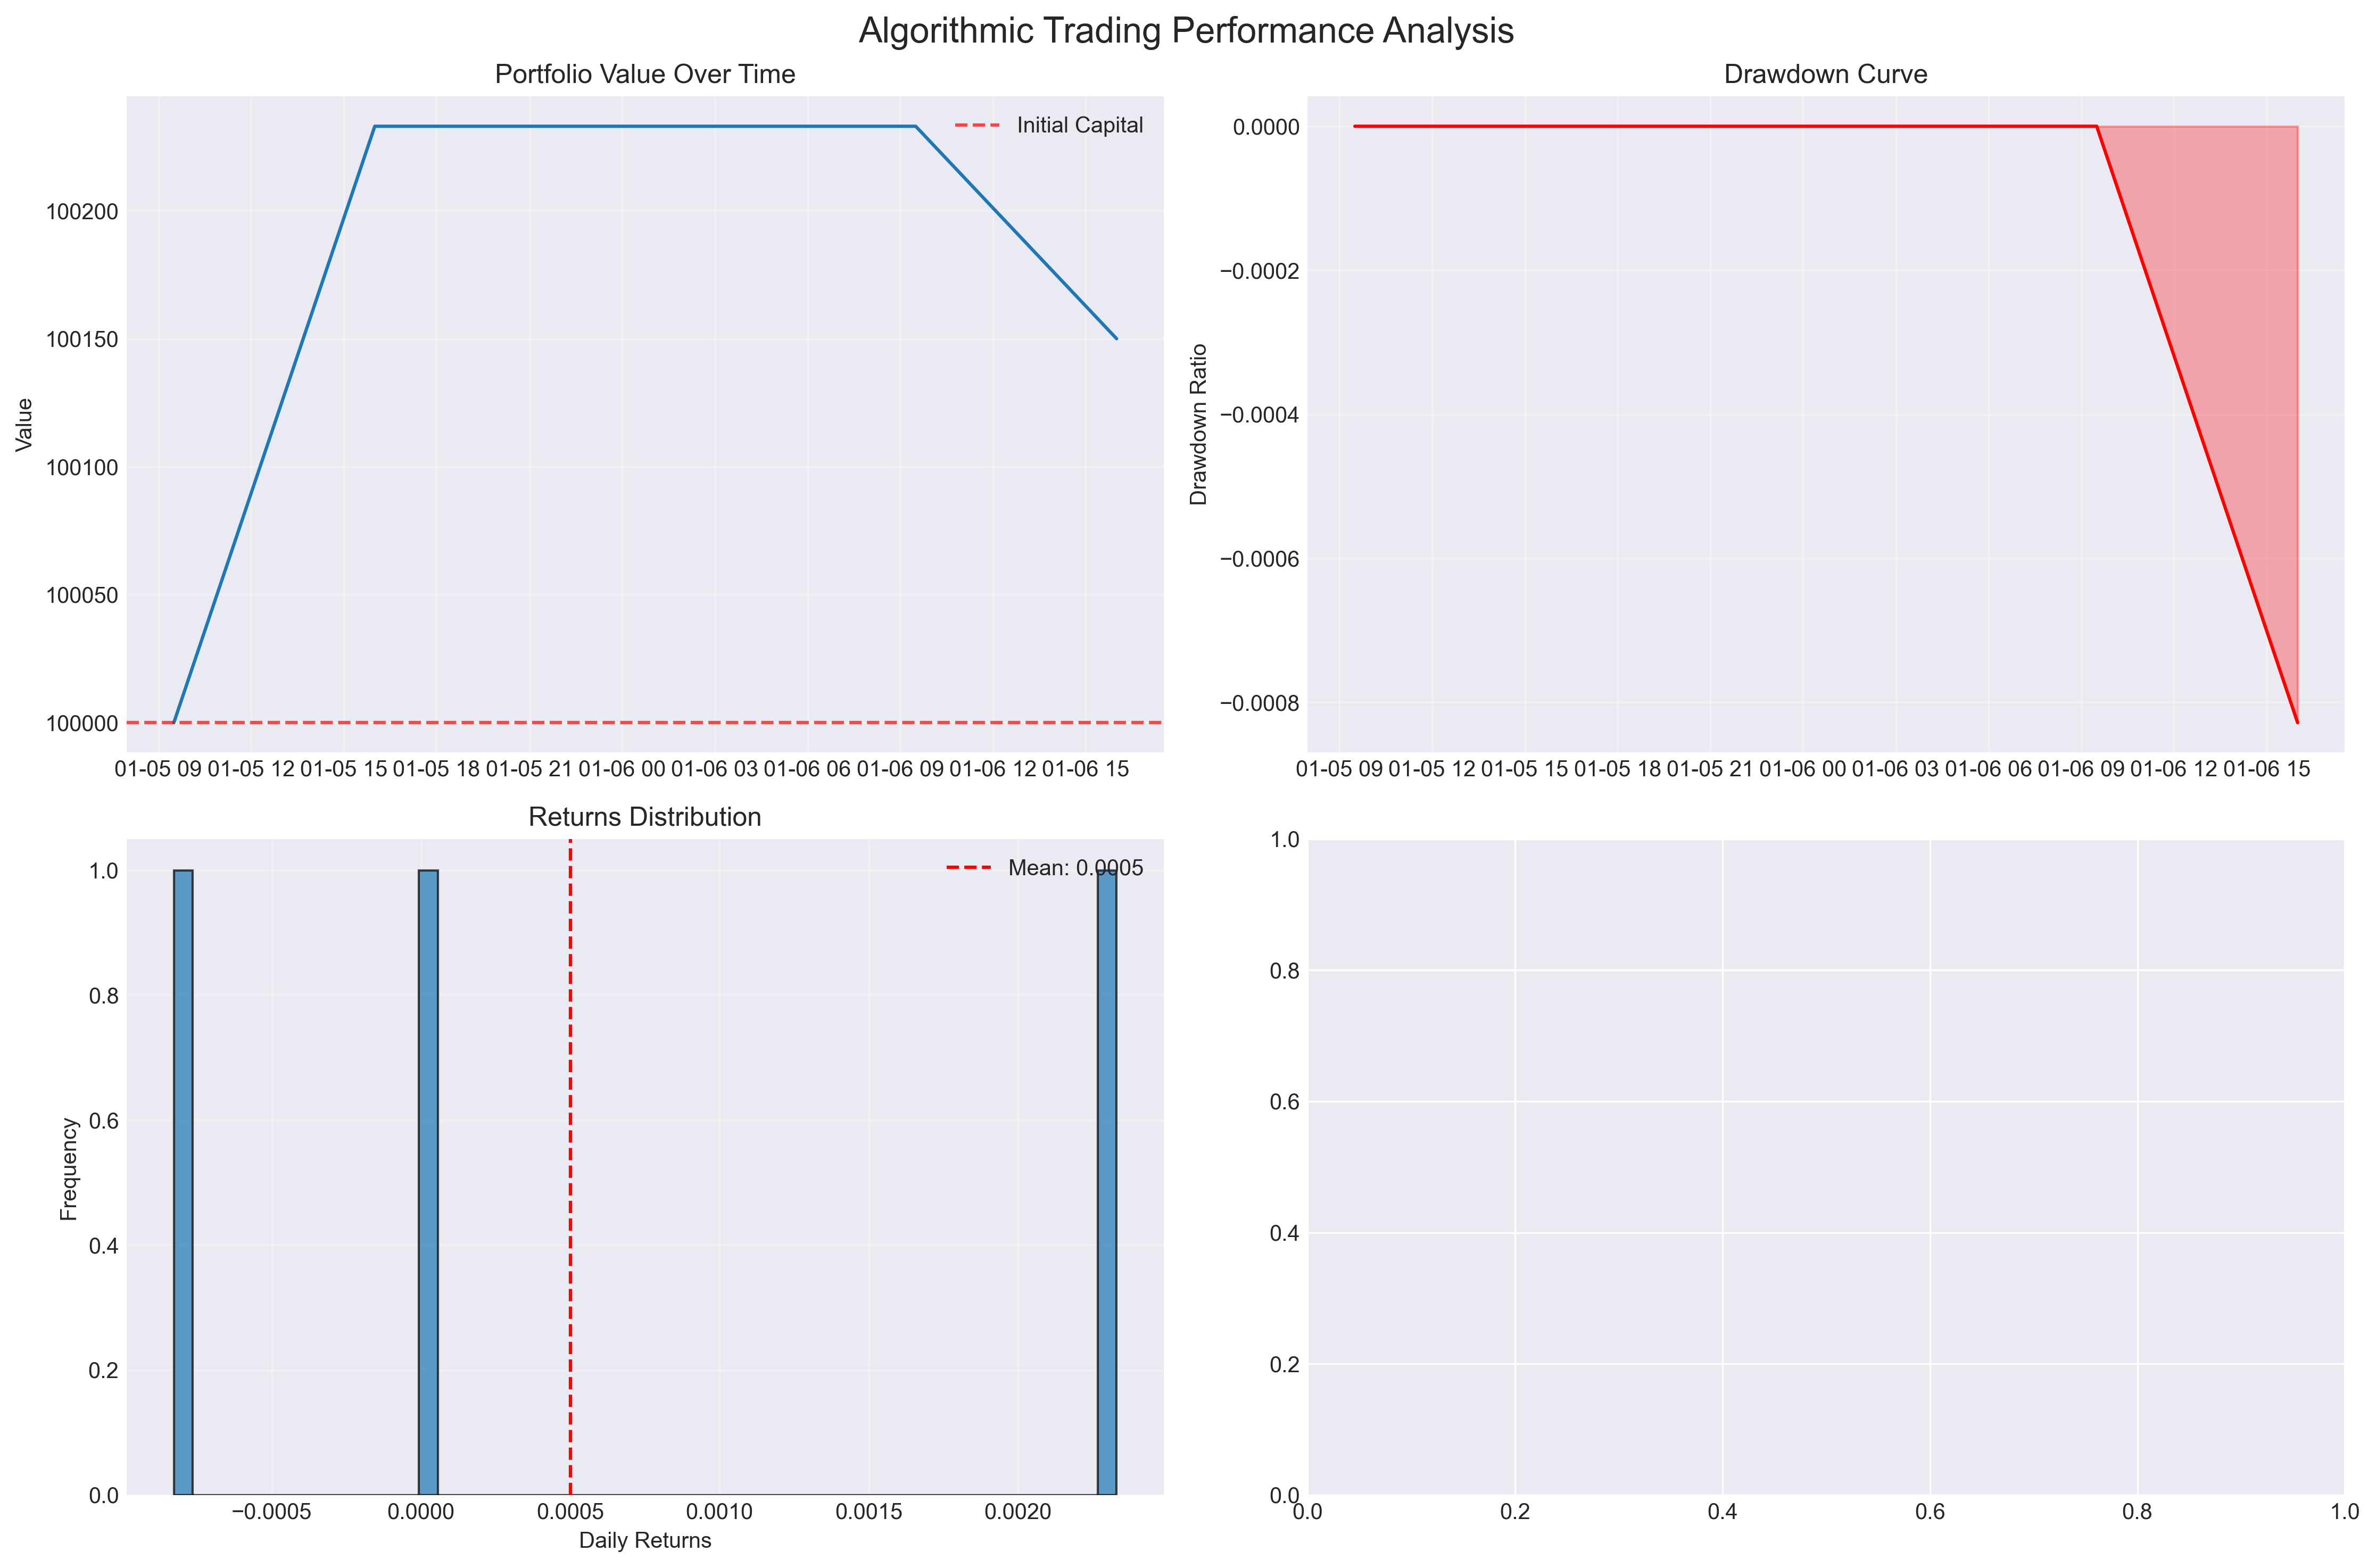

In [8]:
# --- Demonstration of PerformanceAnalyzer ---
import json
import logging
import os

# Assuming SuppressLogger is defined in a previous cell, as it is in your notebook.
# If not, you would need to include its definition here.
from contextlib import contextmanager

from IPython.display import Markdown, display

# Import the necessary classes from your framework
from patf_trading_framework.performance_analyzer import PerformanceAnalyzer, TradeRecord


@contextmanager
def SuppressLogger(loggers, level=logging.WARNING):
    """A context manager to temporarily change the logging level for specified loggers."""
    if not isinstance(loggers, list):
        loggers = [loggers]

    original_levels = {}
    for logger_name in loggers:
        logger_instance = logging.getLogger(logger_name)
        original_levels[logger_name] = logger_instance.level
        logger_instance.setLevel(level)

    try:
        yield
    finally:
        for logger_name, original_level in original_levels.items():
            logging.getLogger(logger_name).setLevel(original_level)

# --- Setup ---
display(Markdown("### Demonstration: `PerformanceAnalyzer` Full Reporting"))

# This assumes the notebook is in the '/notebooks' directory, so the parent is the project root.
project_root = Path.cwd()
# If your notebook is in /notebooks, use Path.cwd().parent
if project_root.name == 'notebooks':
    project_root = project_root.parent

output_chart_dir = project_root / "output" / "charts"
os.makedirs(output_chart_dir, exist_ok=True)
print(f"Chart will be saved in: {output_chart_dir.resolve()}")


# 1. Instantiate the analyzer
analyzer = PerformanceAnalyzer(initial_capital=100000.0)

# 2. Simulate adding trade records
print("\nPopulating analyzer with mock trade and portfolio data...")
mock_trades = [
    TradeRecord(timestamp=datetime(2023, 1, 5, 10, 5), symbol='SPY', side='buy', quantity=50, price=380.50, commission=1.0, order_id='order1', slippage=0.02),
    TradeRecord(timestamp=datetime(2023, 1, 5, 14, 30), symbol='SPY', side='sell', quantity=50, price=385.20, commission=1.0, order_id='order2', slippage=0.03),
    TradeRecord(timestamp=datetime(2023, 1, 6, 11, 0), symbol='AAPL', side='buy', quantity=25, price=130.10, commission=1.0, order_id='order3', slippage=0.01),
]
for trade in mock_trades:
    analyzer.add_trade(trade)

# 3. Simulate adding portfolio value snapshots
analyzer.portfolio_values = [
    (datetime(2023, 1, 5, 9, 30), 100000.0),
    (datetime(2023, 1, 5, 16, 0), 100233.0),
    (datetime(2023, 1, 6, 9, 30), 100233.0),
    (datetime(2023, 1, 6, 16, 0), 100150.0)
]
analyzer.latest_market_prices = {'SPY': 385.20, 'AAPL': 129.80}

# 4. Generate and print the complete JSON report
print("\n--- Generating Full Performance Report (JSON) ---")
full_report_json = analyzer.generate_performance_report()
report_obj = json.loads(full_report_json)
print(json.dumps(report_obj, indent=2))

# 5. Generate and display the charts
print("\n--- Generating Performance Charts ---")
chart_path = output_chart_dir / 'notebook_demo_perf.png'

# This will hide the verbose DEBUG logs from matplotlib during chart generation.
with SuppressLogger(['matplotlib', 'matplotlib.font_manager'], level=logging.WARNING):
    analyzer.plot_performance_charts(save_path=chart_path)

display(Image(filename=chart_path))

### Demonstration: `ConsistencyValidator` for Backtest vs. Live Analysis

In [9]:
# --- Demonstration of ConsistencyValidator ---
import json

from IPython.display import Markdown, display

# Import the necessary class from your framework
from patf_trading_framework.consistency_validator import ConsistencyValidator

# 1. Instantiate the validator
validator = ConsistencyValidator()

# 2. Create mock data simulating a backtest and a live trading session
print("Creating mock data for backtest and live trading scenarios...")
mock_backtest_data = {
    "signals": [
        {"timestamp": "2023-01-10 10:04:58", "signal": 1.0}, # Signal to buy
    ],
    "trades": [
        {"timestamp": "2023-01-10 10:05:00", "symbol": "AAPL", "side": "buy", "quantity": 10, "price": 130.00}
    ],
    "performance": {
        "total_return": 0.02,
        "sharpe_ratio": 1.5,
        "max_drawdown": -0.01,
        "win_rate": 1.0,
    }
}

# Live data shows slight delays and price differences (slippage)
mock_live_data = {
    "signals": [
        {"timestamp": "2023-01-10 10:05:01", "signal": 0.99}, # Similar signal, slightly different value
    ],
    "trades": [
        {"timestamp": "2023-01-10 10:05:15", "symbol": "AAPL", "side": "buy", "quantity": 10, "price": 130.05}
    ],
    "performance": {
        "total_return": 0.018,
        "sharpe_ratio": 1.35, # Performance is slightly lower
        "max_drawdown": -0.012,
        "win_rate": 1.0,
    }
}

# 3. Run the validation process
print("\nRunning consistency validation...")
results = validator.validate_consistency(mock_backtest_data, mock_live_data)

# 4. Generate and print the comprehensive report
print("\n--- Generated Consistency Validation Report ---")
report = validator.generate_validation_report(results)
print(json.dumps(report, indent=2, default=str))

2025-08-19 17:51:14 - patf_trading_framework.consistency_validator - INFO - Registered test: SignalConsistencyTest
2025-08-19 17:51:14 - patf_trading_framework.consistency_validator - INFO - Registered test: ExecutionConsistencyTest
2025-08-19 17:51:14 - patf_trading_framework.consistency_validator - INFO - Registered test: PerformanceConsistencyTest
2025-08-19 17:51:14 - patf_trading_framework.consistency_validator - INFO - Consistency validator initialized.
2025-08-19 17:51:14 - patf_trading_framework.consistency_validator - INFO - Starting consistency validation...
2025-08-19 17:51:14 - patf_trading_framework.consistency_validator - INFO - Test completed: Signal Consistency - Failed (Score: 0.00)
2025-08-19 17:51:14 - patf_trading_framework.consistency_validator - INFO - Test completed: Execution Consistency - Failed (Score: 0.65)
2025-08-19 17:51:14 - patf_trading_framework.consistency_validator - INFO - Test completed: Performance Consistency - Passed (Score: 1.00)
2025-08-19 17:5

Creating mock data for backtest and live trading scenarios...

Running consistency validation...

--- Generated Consistency Validation Report ---
{
  "timestamp": "2025-08-19 17:51:14.185729",
  "overall_status": "Needs Improvement",
  "overall_score": 0.5499999999999999,
  "passed_tests": 1,
  "total_tests": 3,
  "pass_rate": 0.3333333333333333,
  "test_results": {
    "SignalConsistencyTest": {
      "passed": false,
      "score": 0.0,
      "warnings_count": 1,
      "recommendations_count": 0
    },
    "ExecutionConsistencyTest": {
      "passed": "False",
      "score": 0.65,
      "warnings_count": 1,
      "recommendations_count": 1
    },
    "PerformanceConsistencyTest": {
      "passed": true,
      "score": 1.0,
      "warnings_count": 0,
      "recommendations_count": 0
    }
  },
  "summary_warnings": [
    "Average price difference is too high: 0.0500",
    "Backtest and live data do not have overlapping time periods"
  ],
  "summary_recommendations": [
    "Check slipp

## The Live Trading Architecture (run_live_trading.py)

> From real-time data to execution


While we design the backtesting engine for historical analysis, we engineer the live trading system (run_live_trading.py) for an entirely different purpose: resilient, efficient, and correct real-time operation. We build this functionality on Python's asyncio library to handle concurrent tasks without blocking, ensuring that we can listen for market data, process signals, and manage orders simultaneously.

This section breaks down the architecture of the live system, explaining how data flows from the broker to a final trade execution.

We have a live trading system that we can deploy in two ways: locally for debugging by running the `run-live` bash command, or more robustly via Docker using a Dockerfile and docker-compose.yml.

### Architectural Flowchart

The following diagram illustrates the flow of information. The BrokerAPIHandler acts as the sole gateway to Alpaca, feeding data into the system via an asyncio.Queue. The EnhancedTradingSystem then processes this data to make trading decisions.

![Architectural Flowchart](images/architectural_flowchart.png)

### Core Components of the Live System

The architecture is modular, with each class having a distinct and clear responsibility. This makes the system easier to maintain, debug, and extend.

1\. EnhancedTradingSystem (The Orchestrator)

  * File: src/patf_trading_framework/scripts/run_live_trading.py

  * Responsibility: This class is the central nervous system of the live trading bot. It initializes all other components and contains the main asynchronous trading_loop. Its primary jobs are to:

    * Read from the Queue: Continuously and asynchronously gets new data items (trades, bars, or account updates) from the asyncio.Queue.

    * Generate Signals: Passes the latest market price to the LiveMeanReversionStrategy to get a trading signal (BUY, SELL, or HOLD).

    * Execute Trades: If a signal is generated and risk checks pass, it calls the BrokerAPIHandler to place an order.

    * Verify State: Periodically (e.g., every 5 minutes), it polls the Alpaca REST API to get the official account and position status, comparing it against the state tracked via the WebSocket. This secondary verification loop is crucial for detecting discrepancies and ensuring the bot's internal state doesn't drift from the broker's reality, fulfilling a key project requirement.

2\. BrokerAPIHandler (The Communications Hub)

* File: src/patf_trading_framework/broker_handler.py

* Responsibility: This class is the single and only interface to the Alpaca API. It encapsulates all external communication, ensuring consistency and preventing issues like multiple WebSocket connections.

  * REST API Operations: It handles all request-response actions, such as placing orders, canceling orders, and fetching account information. It has built-in retry logic to handle transient network issues.

  * WebSocket Stream Management: It sets up and manages the real-time WebSocket connection. Crucially, it defines asynchronous callback functions (handle_trade, handle_bar, handle_trade_update). When the WebSocket receives a new piece of data, the corresponding callback's only job is to immediately put that data into the asyncio.Queue.

3\. asyncio.Queue (The Data Buffer)

* File: A standard Python asyncio library component, initialized within EnhancedTradingSystem.

* Responsibility: To decouple data ingestion from data processing. This is a fundamental pattern for building robust, high-throughput systems.

  * The Flow:

    * A WebSocket event occurs (e.g., a new trade for 'AAPL').
  
    * The BrokerAPIHandler's handle_trade callback is instantly triggered and puts the trade data onto the queue. This action is extremely fast and non-blocking.
  
    * The main trading_loop in EnhancedTradingSystem, which might be busy with other tasks, will get the trade data from the queue whenever it's ready to process it.
  
  * The Benefit (Preventing Backpressure): If the strategy logic were to become slow or complex, the queue acts as a buffer. The WebSocket can continue to receive new data and fill the queue without dropping messages or blocking the connection.

4\. LiveMeanReversionStrategy & TradingState (The Live Logic)

* File: src/patf_trading_framework/live_components.py

* Responsibility: These classes contain the logic and state management specifically for the live environment, which is fundamentally different from backtesting.

  * LiveMeanReversionStrategy: This is not a backtrader strategy. It's a lightweight Python class designed to work with single, real-time price updates. It maintains its own internal state (a deque of the last N prices) and has a get_signal() method that calculates the Z-Score based on its current price history.

  * TradingState: This class acts as the live bot's single source of truth. It tracks critical information like the current position quantity for the target symbol, any active order IDs, and the last known cash balance. It is updated by events from the WebSocket stream (e.g., an order fill confirmation) and is periodically synchronized by the REST verification loop in EnhancedTradingSystem. This centralized state management makes the system's behavior explicit and far easier to debug.

### Sample Operational Walkthrough

The following log excerpt demonstrates a typical session walkthrough, from initialization to graceful shutdown. It showcases the real-time flow of events, including WebSocket connection, data ingestion, signal generation, and the periodic state reconciliation that ensures system integrity. 

We can start the live trader system via the command `run-live`. The following snippet showcases the script's role as a direct entry point for deployment (I curated slightly to improve readability).

```log
# Command to start the live trading bot from the project root
$ run-live

# 1. Initialization: System starts, loads configuration from config.yml.
2025-08-20 09:30:00 - patf_trading_framework.scripts.run_live_trading - INFO - Enhanced trading system initialization completed
2025-08-20 09:30:00 - patf_trading_framework.broker_handler - INFO - Initializing Alpaca API Handler for URL: https://paper-api.alpaca.markets
2025-08-20 09:30:00 - patf_trading_framework.live_components - INFO - LiveMeanReversionStrategy for AAPL initialized with: Period=20, UpperZ=2.0, LowerZ=-2.0...

# 2. Connection: Establishes a connection to the Alpaca WebSocket stream and subscribes to data.
2025-08-20 09:30:01 - patf_trading_framework.broker_handler - INFO - Setting up Alpaca data stream...
2025-08-20 09:30:01 - patf_trading_framework.broker_handler - INFO - Subscribed to trades for: ['AAPL'] (using custom handler)
2025-08-20 09:30:01 - patf_trading_framework.broker_handler - INFO - Subscribed to trade/account updates (using custom handler).

# 3. Data Ingestion: Receives the first real-time trade data and puts it into the internal asyncio queue.
2025-08-20 09:30:02 - patf_trading_framework.scripts.run_live_trading - DEBUG - Processing item from queue: Type=trade, Item={'symbol': 'AAPL', 'price': 228.45, ...}

# 4. Signal Generation: The strategy component processes the new price and generates a signal (in this case, 'HOLD').
2025-08-20 09:30:02 - patf_trading_framework.live_components - INFO - Signal: HOLD for AAPL (Z-score 0.35, Position: 0.0)

# 5. Periodic State Reconciliation: The secondary verification loop runs, polling the REST API to confirm state integrity.
2025-08-20 09:35:00 - patf_trading_framework.scripts.run_live_trading - INFO - [RECONCILE] Starting periodic account and position refresh...
2025-08-20 09:35:01 - patf_trading_framework.scripts.run_live_trading - INFO - [RECONCILE] State consistent for AAPL: Stream and REST API both show position of 0.0.

# 6. Graceful Shutdown: The system receives a shutdown signal (Ctrl+C) and terminates cleanly.
2025-08-20 09:40:00 - patf_trading_framework.scripts.run_live_trading - INFO - Stopping trading system...
2025-08-20 09:40:01 - patf_trading_framework.broker_handler - INFO - Data stream stopped successfully.
```

This log demonstrates the system design: the BrokerAPIHandler connects to the stream, the EnhancedTradingSystem processes queued data, the LiveMeanReversionStrategy generates signals, and the secondary verification loop periodically validates the system's state against the broker's official record via the REST API. This demonstrates a robust and observable execution path from real-time data to a trading decision.

### Live System Reliability: Demonstrating State Verification and Correction

A key requirement for a robust trading system is the ability to handle discrepancies between real-time data streams (WebSockets) and the authoritative state from the broker's REST API. The following simulation demonstrates how the `EnhancedTradingSystem` detects and corrects such a mismatch.

**Scenario:**

1. The system's internal state believes we have 0 shares of AAPL.

2. A WebSocket message arrives, confirming an order to BUY 10 shares has been filled. The system updates its internal state to 10.

3. Due to a potential lag, the REST API, when polled moments later, still reports the position as 0 shares.

4. The system's periodic verification loop runs, detects the mismatch, logs a warning, and corrects its internal state back to 0 based on the REST API's authoritative data.

In [10]:
# --- Imports for the demo ---
import asyncio
from unittest.mock import MagicMock

# --- Import system components ---
from patf_trading_framework.scripts.run_live_trading import EnhancedTradingSystem

MockPosition = lambda qty_str: type("MockPosition", (), {"qty": str(qty_str)})()

# --- The Asynchronous Demo Function ---
async def demonstrate_state_correction():
    print("--- Starting State Correction Demonstration ---")
    
    sys = EnhancedTradingSystem(config)
    sys.initialize_components()
    print("System initialized.")
    
    sys.trading_state.update_position(0.0)
    logger.info(f"Initial state: Position for {sys.trading_state.symbol} is {sys.trading_state.current_position_qty}")

    mock_fill_update = {
      "event": "fill",
      "order_id": "abc123_mock_fill", "status": "filled",
      "filled_qty": "10", "filled_price": "175.25", "remaining_qty": "0"
    }
    await sys.handle_trade_update(mock_fill_update)
    
    original_get_position = sys.broker_handler.get_position
    
    sys.broker_handler.get_position = MagicMock(return_value=MockPosition(0.0))
    logger.info("[SIMULATION] BrokerAPIHandler.get_position is now mocked to return a stale position of 0.")

    await sys._verify_state_once()
    
    sys.broker_handler.get_position = original_get_position
    logger.info("[SIMULATION] Restored original BrokerAPIHandler.get_position method.")
    print("\n--- Demonstration Complete ---")

# --- Run the demonstration ---
await demonstrate_state_correction()

2025-08-19 17:51:14 - patf_trading_framework.risk_manager - INFO - RiskManager initialized with config: VaR window=252, confidence level=95.0%, Max Participation=0.02, Max Gross Exposure=1.5
2025-08-19 17:51:14 - patf_trading_framework.performance_analyzer - INFO - Performance analyzer initialized with initial capital: 100,000.00
2025-08-19 17:51:14 - patf_trading_framework.exception_handler - INFO - Exception handler initialized.
2025-08-19 17:51:14 - patf_trading_framework.consistency_validator - INFO - Registered test: SignalConsistencyTest
2025-08-19 17:51:14 - patf_trading_framework.consistency_validator - INFO - Registered test: ExecutionConsistencyTest
2025-08-19 17:51:14 - patf_trading_framework.consistency_validator - INFO - Registered test: PerformanceConsistencyTest
2025-08-19 17:51:14 - patf_trading_framework.consistency_validator - INFO - Consistency validator initialized.
2025-08-19 17:51:14 - patf_trading_framework.scripts.run_live_trading - INFO - Enhanced trading syste

--- Starting State Correction Demonstration ---


2025-08-19 17:51:14 - urllib3.connectionpool - DEBUG - https://paper-api.alpaca.markets:443 "GET /v2/account HTTP/1.1" 200 None
2025-08-19 17:51:14 - patf_trading_framework.broker_handler - DEBUG - Successfully retrieved account information. ID: 006789bf-2bef-4299-a068-6abfd7d8bb01
2025-08-19 17:51:14 - patf_trading_framework.broker_handler - INFO - Successfully connected to Alpaca paper trading account. Account ID: 006789bf-2bef-4299-a068-6abfd7d8bb01, Status: ACTIVE
2025-08-19 17:51:14 - patf_trading_framework.broker_handler - INFO - Current Buying Power: 401056.48
2025-08-19 17:51:14 - patf_trading_framework.live_components - INFO - LiveMeanReversionStrategy for AAPL initialized with: Period=20, UpperZ=2.0, LowerZ=-2.0, ExitThresholdZ=0.0
2025-08-19 17:51:14 - patf_trading_framework.exception_handler - INFO - Error callback registered for category: network
2025-08-19 17:51:14 - patf_trading_framework.exception_handler - INFO - Error callback registered for category: api
2025-08-19 1

System initialized.


2025-08-19 17:51:15 - urllib3.connectionpool - DEBUG - https://paper-api.alpaca.markets:443 "GET /v2/account HTTP/1.1" 200 None
2025-08-19 17:51:15 - patf_trading_framework.broker_handler - DEBUG - Successfully retrieved account information. ID: 006789bf-2bef-4299-a068-6abfd7d8bb01
2025-08-19 17:51:15 - patf_trading_framework.live_components - DEBUG - Updated account state: Cash=100264.12, PortfolioValue=100264.12
2025-08-19 17:51:15 - patf_trading_framework.scripts.run_live_trading - WARNING - [VERIFY] Position mismatch for AAPL: Stream state is 10.0, but REST API state is 0.0. Syncing.
2025-08-19 17:51:15 - patf_trading_framework.live_components - INFO - Updating position for AAPL from 10.0 to 0.0
2025-08-19 17:51:15 - patf_trading_framework.scripts.run_live_trading - INFO - [VERIFY] Sync complete. Position for AAPL is now 0.0.
2025-08-19 17:51:15 - patf_trading_framework.scripts.run_live_trading - INFO - [VERIFY] Verification pass complete.
2025-08-19 17:51:15 - __main__ - INFO - [S


--- Demonstration Complete ---


## Performance Dashboard (dashboard_app.py)

> Visualizing risk and P&L with streamlit and timescaleDB


To fulfill the project's optional recipe for a risk dashboard, this framework includes an interactive web application built with Streamlit. This dashboard serves as a powerful tool for monitoring and analyzing the performance of trading strategies, whether they are running live or have been backtested.

It directly connects to the TimescaleDB database, which acts as the single source of truth for all performance and trade data. This ensures that the visualizations are always based on the most up-to-date information logged by the trading system.

The key features of the dashboard include:

* Key Performance Indicators (KPIs): At-a-glance metrics like Total Return, Sharpe Ratio, Maximum Drawdown, and daily Value-at-Risk (VaR).

* Portfolio Value Chart: An interactive time-series chart showing the growth of the portfolio's equity over the selected period.

* Recent Trades Log: A sortable and searchable table displaying all trades executed within the chosen timeframe, loaded directly from the trade_logs table in the database.

### How to Run the Dashboard

To start the web application, run the following command from the root directory of the project:

```bash
run-dashboard
```

After running the command, Streamlit will start a local web server and the default web browser should automatically open a new tab with the interactive dashboard.

### How It Connects to the Database

The run_dashboard.py script leverages the same centralized configuration system as the rest of the framework. It loads the config.yml file to get the necessary database credentials (host, user, password, etc.) and then uses the DBHandler to query the performance_snapshots and trade_logs tables. This ensures that the dashboard, back-tester, and live trader all share a consistent and reliable connection to the same data source.

## Docker (docker-compose.yml)

> Robust, reproducible, and ready for deployment


While running the framework locally is ideal for development, the Docker and Docker Compose setup is what makes this project robust, reproducible, and ready for a CI/CD deployment. It ensures that the trading application and its database run in an isolated and consistent environment, no matter what machine it's on.

Let's break down the docker-compose.yml file to understand the architecture. This single file orchestrates the entire application stack.

### Service-by-Service Analysis

The file defines two main services: db and trading-bot.

1\. The db Service (TimescaleDB)

This service runs the high-performance TimescaleDB database, which is essential for storing market data, trades, and performance snapshots.

* image: timescale/timescaledb-ha:pg16-all: It uses the official, production-ready TimescaleDB image with High Availability features.

* restart: always: Ensures the database automatically restarts if it ever crashes.

* environment: Sets up the database user and name. Note that POSTGRES_PASSWORD is passed in securely.

* volumes: - timescale_data:/var/lib/postgresql/data: This is critical for data persistence. It maps the database's internal data directory to a Docker-managed volume named timescale_data.

* ports: - "5432:5432": Exposes the database port to the host machine, allowing us to connect with external tools like DBeaver or pgAdmin for debugging and inspection.

* healthcheck: This block continuously checks if the database is ready to accept connections. This is crucial for the startup order.

2\. The trading-bot Service

This is the core application container, built from the Dockerfile in our project.

* build: .: Tells Docker Compose to build an image from the Dockerfile in the current directory.

* image: patf-trading-framework:latest: Names the built image for clarity.

* environment: This section defines all the environment variables the Python application needs to run, including API keys and the database connection details. Notice DB_HOST=db—the container can refer to the database service by its service name (db).

* volumes: - ./output:/app/output: This mounts the local ./output folder on your machine to the /app/output folder inside the container, ensuring any generated logs or charts are immediately available on your host system.

* depends_on: This directive controls the startup order, which is a key feature for stability.

### Key Architectural Features for Robustness

This docker-compose.yml file has several key design decisions that make it robust and suitable for production use:

1\. Guaranteed Startup Order with depends_on

The trading-bot service includes this block:

```yaml
depends_on:
  db:
    condition: service_healthy
```

This prevents a common race condition where the application starts before the database is ready, which would cause immediate connection errors. The condition: service_healthy instruction tells Docker Compose to wait until the db service's healthcheck passes before starting the trading-bot container.

2\. Data Persistence with volumes

The framework uses two types of volumes to ensure no data is lost:

* Named Volume (timescale_data): Used by the db service. Docker directly manages this service and it is the standard, high-performance way to persist database data. The data inside timescale_data will survive even if you run docker-compose down and remove the containers.

* Bind Mount (./output:/app/output): Used by the trading-bot service. This directly links a folder on our host machine to a folder inside the container. It's perfect for development and for easily accessing generated artifacts like logs, reports, and charts without having to enter the container.

3\. Secure Secret Management

You'll notice that sensitive values like APCA_API_KEY_ID and POSTGRES_PASSWORD are not hardcoded in the docker-compose.yml file. This is a critical security best practice.

Docker Compose automatically looks for a file named .env in the project's root directory. It reads the variables from that file and makes them available inside the docker-compose.yml configuration.

* For the trading-bot service, variables like APCA_API_KEY_ID are passed directly into the container's environment.

* For the db service, the POSTGRES_PASSWORD variable from the .env file is used to set the database password.

* In the trading-bot service, DB_PASSWORD=${POSTGRES_PASSWORD} ensures both containers use the same password.

This approach keeps our secrets out of our Docker image and out of our version-controlled code (since .env is listed in .gitignore), which is essential for secure development and deployment.


### Contents of `docker-compose.yml`

This is the project's current `docker-compose.yml` configuration. It defines two core services: `db` and `trading-bot`.

In [11]:
# --- Load and Display docker-compose.yml ---

import os

from IPython.display import Markdown, display

# Define the relative path to the docker-compose.yml file.
# We assume this notebook is in the /notebooks/ directory, and the
# configuration file is located in the project's root directory.
docker_compose_path = '../docker-compose.yml'

file_content = ""
error_message = ""

try:
    # Use a try-except block to gracefully handle cases where the file does not exist.
    with open(docker_compose_path, encoding='utf-8') as f:
        file_content = f.read()
except FileNotFoundError:
    error_message = (
        f"**Error**: The `docker-compose.yml` file was not found at '{os.path.abspath(docker_compose_path)}'.\n"
        "Please make sure you are running the Jupyter Notebook from the project's root directory, or that the file path is correct."
    )

# Use an f-string to create the Markdown-formatted output.
# We wrap the file content in a yaml code block for syntax highlighting.
markdown_output = f"""
```yaml
{file_content}
```
{error_message}
"""

# Use the display function to render the Markdown content.
display(Markdown(markdown_output))


```yaml
services:
  db:
    image: timescale/timescaledb-ha:pg16-all
    container_name: trading_db
    restart: always
    environment:
      - POSTGRES_USER=trading_user
      # Docker Compose automatically populates the POSTGRES_PASSWORD variable by searching for it first in a local .env file and then in the host machine's environment variables.
      - POSTGRES_PASSWORD
      - POSTGRES_DB=trading_db
    volumes:
      - timescale_data:/var/lib/postgresql/data
    ports:
      - "5432:5432" # Exposes the database port to the host, allowing external tools to connect for debugging
    healthcheck:
      test: ["CMD-SHELL", "pg_isready -U trading_user -d trading_db"]
      interval: 10s
      timeout: 5s
      retries: 5

  trading-bot:
    # Build the image from the Dockerfile in the current directory
    build: .
    # Name the image
    image: patf-trading-framework:latest
    # Load environment variables from the host machine
    environment:
      - APCA_API_KEY_ID
      - APCA_API_SECRET_KEY
      - ALPACA_BASE_URL=https://paper-api.alpaca.markets
      - PYTHONUNBUFFERED=1
      # Environment variables for the database connection
      - DB_HOST=db # Use the service name ('db') as the hostname to connect to the database container
      - DB_PORT=5432
      - DB_USER=trading_user
      # Like the database password, this value is also loaded automatically from the .env file.
      - DB_PASSWORD=${POSTGRES_PASSWORD}
      - DB_NAME=trading_db
    # Mount the output directory for persistent data
    volumes:
      - ./output:/app/output
    # Ensure the container stops gracefully
    stop_grace_period: 1m
    # Restart policy (optional, but useful for production)
    restart: unless-stopped
    # Ensures this service waits for the database to be healthy before starting
    depends_on:
      db:
        condition: service_healthy

volumes:
  timescale_data:
```



## The Cron-style Scheduling (GitHub Actions)

> Automated & scheduled operations


The workflow file below defines two critical scheduled jobs:

* Daily Data Update (`update-data`):
  * Schedule: runs at 5:00 AM UTC every day (`cron: '0 5 * * *'`).
  * Action: executes the `run-update-data` script. This ensures our TimescaleDB database always has the latest market data from the previous trading day, which is essential for running accurate backtests.

* Weekly Backtest (`run-weekly-backtest`):
  * Schedule: runs at 6:00 AM UTC every Sunday (`cron: '0 6 * * 0'`).
  * Action: executes the `run-backtest` script. This serves as a regular health check, re-running our strategies and optimizations against the latest data to ensure continued performance and to spot any potential model drift.

### Secure and Robust Execution

The execution process is both secure and robust:

* Secure Secrets: API keys and database passwords are not stored in the file. They are pulled from GitHub Secrets (`${{ secrets.APCA_API_KEY_ID }}`), which is the industry standard for managing sensitive information in CI/CD pipelines.

* Dockerized Environment: the command `docker compose run --rm trading-bot run-update-data` demonstrates the power of the architecture. The GitHub Actions runner doesn't just run a Python script; it uses Docker Compose to build and run the `trading-bot` service, ensuring all dependencies and configurations are identical to our live environment, before executing the command inside the container.


In [12]:
# --- Load and Display the GitHub Actions schedule.yml file ---

import os

from IPython.display import Markdown, display

# Define the relative path to the schedule.yml file.
# This assumes the notebook is in a subdirectory (like /notebooks/) of the project root.
schedule_file_path = '../.github/workflows/schedule.yml'

file_content = ""
error_message = ""

try:
    # Use a try-except block to handle cases where the file does not exist.
    with open(schedule_file_path, encoding='utf-8') as f:
        file_content = f.read()
except FileNotFoundError:
    error_message = (
        f"**Error**: The `schedule.yml` file was not found at '{os.path.abspath(schedule_file_path)}'.\n"
        "Please ensure the file path is correct relative to the notebook's location."
    )

# Use an f-string to create the Markdown-formatted output.
# We wrap the file content in a yaml code block for syntax highlighting.
markdown_output = f"""
### **Contents of `.github/workflows/schedule.yml`**

This is the project's current scheduling configuration file, managed by GitHub Actions.

```yaml
{file_content}
```
{error_message}
"""

# Use the display function to render the Markdown content.
display(Markdown(markdown_output))


### **Contents of `.github/workflows/schedule.yml`**

This is the project's current scheduling configuration file, managed by GitHub Actions.

```yaml
name: Scheduled Tasks

on:
  schedule:
    # Runs data update at 5:00 AM UTC every day (around midnight EST)
    - cron: '0 5 * * *'
    # Runs backtest at 6:00 AM UTC every Sunday
    - cron: '0 6 * * 0'

jobs:
  update-data:
    if: github.event.schedule == '0 5 * * *' # Only run at the data update schedule
    runs-on: ubuntu-latest
    steps:
      - name: Checkout code
        uses: actions/checkout@v3

      - name: Create .env file
        run: |
          echo "APCA_API_KEY_ID=${{ secrets.APCA_API_KEY_ID }}" >> .env
          echo "APCA_API_SECRET_KEY=${{ secrets.APCA_API_SECRET_KEY }}" >> .env
          echo "POSTGRES_PASSWORD=${{ secrets.POSTGRES_PASSWORD }}" >> .env
          echo "ALPACA_BASE_URL=https://paper-api.alpaca.markets" >> .env

      - name: Run Data Update Task
        run: docker compose run --rm trading-bot run-update-data

  run-weekly-backtest:
    if: github.event.schedule == '0 6 * * 0' # Only run at the back-test schedule
    runs-on: ubuntu-latest
    steps:
      - name: Checkout code
        uses: actions/checkout@v3

      - name: Create .env file
        run: |
          echo "APCA_API_KEY_ID=${{ secrets.APCA_API_KEY_ID }}" >> .env
          echo "APCA_API_SECRET_KEY=${{ secrets.APCA_API_SECRET_KEY }}" >> .env
          echo "POSTGRES_PASSWORD=${{ secrets.POSTGRES_PASSWORD }}" >> .env
          echo "ALPACA_BASE_URL=https://paper-api.alpaca.markets" >> .env

      - name: Run Weekly Back-test Task
        run: docker compose run --rm trading-bot run-backtest
```



## Conclusion

> Closing remarks


This project successfully developed the Python Algorithmic Trading Framework (PATF), a comprehensive and production-ready system for designing and deploying trading strategies. We implemented and validated two distinct models: a trend-following strategy using EMA/ADX and a mean-reversion strategy using a Kalman-filtered Z-Score. The backtesting results demonstrated that both strategies could operate as designed, with the trend-following model capturing sustained price movements and the mean-reversion model capitalizing on short-term oscillations.

Limitations and future work:

While the PATF provides a robust foundation, it is essential to acknowledge its limitations and identify areas for future improvement:

* Static Risk Models: The current implementation uses static parameters for risk management, such as a fixed market impact coefficient (`λ`). In reality, market impact is dynamic and regime-dependent. Future work should explore dynamic models where `λ` is a function of market volatility and volume.

* Execution Logic: The order execution logic is currently limited to basic market and limit orders. To reduce transaction costs further, the framework could be enhanced with more sophisticated execution algorithms, such as Time-Weighted Average Price (TWAP) or Volume-Weighted Average Price (VWAP).

* Backtesting Fidelity: The current backtester does not account for order book dynamics or queue priority. A higher-fidelity backtesting engine could be developed by incorporating historical Level 2 (order book) data to provide more realistic slippage and fill probability simulations.

* Strategy Scope: The strategy library could be expanded to include more complex models, such as multi-asset statistical arbitrage (pairs trading) or strategies based on machine learning predictions.